# 1. Analyse exploratoire

### Import des modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder

#### Affichage des données

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

### Import des sources de données

In [3]:
extrait_eval = pd.read_csv("extrait_eval.csv")
extrait_sirh = pd.read_csv("extrait_sirh.csv")
extrait_sondage = pd.read_csv("extrait_sondage.csv")

### Dataframe extrait_eval

In [4]:
print(f"Il y a {extrait_eval.shape[0]} lignes et {extrait_eval.shape[1]} colonnes dans extrait_eval")

Il y a 1470 lignes et 10 colonnes dans extrait_eval


In [5]:
extrait_eval.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


Ecrivons une fonction pour avoir du détail sur les colonnes d'un dataframe (cela nous servira pour les autres dataframes)

In [6]:
def metadata_extrait(df):
    metadata_list=[]
    for col in df.columns:
        serie = df[col]
        info = {
            'colonne': col,
            'type': serie.dtype,
            'nb_unique': serie.nunique(),
            'pct_manquant': round(serie.isnull().mean(),2)
        }
        if pd.api.types.is_numeric_dtype(serie):
            info['min'] = serie.min()
            info['max'] = serie.max()
            info['avg'] = serie.mean()
        else:
            info['min'] = '-'
            info['max'] = '-'
            info['avg'] = '-'
        metadata_list.append(info)
    metadata=pd.DataFrame(metadata_list)
    return metadata

In [7]:
metadata_extrait(extrait_eval)

,colonne,type,nb_unique,pct_manquant,min,max,avg
0,satisfaction_employee_environnement,int64,4,0.0,1,4,2.721769
1,note_evaluation_precedente,int64,4,0.0,1,4,2.729932
2,niveau_hierarchique_poste,int64,5,0.0,1,5,2.063946
3,satisfaction_employee_nature_travail,int64,4,0.0,1,4,2.728571
4,satisfaction_employee_equipe,int64,4,0.0,1,4,2.712245
5,satisfaction_employee_equilibre_pro_perso,int64,4,0.0,1,4,2.761224
6,eval_number,str,1470,0.0,-,-,-
7,note_evaluation_actuelle,int64,2,0.0,3,4,3.153741
8,heure_supplementaires,str,2,0.0,-,-,-
9,augementation_salaire_precedente,str,15,0.0,-,-,-


Tout le jeu de donnée est renseigné, sans incohérence manifeste.

`eval_number` a 1470 valeurs différentes, autant que le nombre de lignes, c'est un identifiant. Aujourd'hui c'est un string, transformons le en integer, ce qui est plus cohérent


In [8]:
def eval_number_integer(valeur):
    valeur=valeur.replace("E_","")
    valeur=int(valeur)
    return(valeur)

In [9]:
extrait_eval['eval_number'] = extrait_eval['eval_number'].apply(eval_number_integer)
metadata_extrait(extrait_eval)

,colonne,type,nb_unique,pct_manquant,min,max,avg
0,satisfaction_employee_environnement,int64,4,0.0,1,4,2.721769
1,note_evaluation_precedente,int64,4,0.0,1,4,2.729932
2,niveau_hierarchique_poste,int64,5,0.0,1,5,2.063946
3,satisfaction_employee_nature_travail,int64,4,0.0,1,4,2.728571
4,satisfaction_employee_equipe,int64,4,0.0,1,4,2.712245
5,satisfaction_employee_equilibre_pro_perso,int64,4,0.0,1,4,2.761224
6,eval_number,int64,1470,0.0,1,2068,1024.865306
7,note_evaluation_actuelle,int64,2,0.0,3,4,3.153741
8,heure_supplementaires,str,2,0.0,-,-,-
9,augementation_salaire_precedente,str,15,0.0,-,-,-


Notons également que `augementation_salaire_precedente` est un string de type "XX %", zoomons sur ses valeurs

In [10]:
extrait_eval['augementation_salaire_precedente'].value_counts()

augementation_salaire_precedente
11 %    210
13 %    209
14 %    201
12 %    198
15 %    101
18 %     89
17 %     82
16 %     78
19 %     76
22 %     56
20 %     55
21 %     48
23 %     28
24 %     21
25 %     18
Name: count, dtype: int64

Nous allons les transformer en entiers (et corriger la faute d'ortographe sur la colonne)

In [11]:
def pourcentage_vers_int(valeur):
    valeur = valeur.replace("%", "")
    valeur = valeur.strip()
    valeur = int(valeur)
    return valeur

In [12]:
extrait_eval = extrait_eval.rename(columns={
    'augementation_salaire_precedente': 'augmentation_salaire_precedente'
})
extrait_eval['augmentation_salaire_precedente'] = extrait_eval['augmentation_salaire_precedente'].apply(pourcentage_vers_int)

In [13]:
metadata_extrait(extrait_eval)

,colonne,type,nb_unique,pct_manquant,min,max,avg
0,satisfaction_employee_environnement,int64,4,0.0,1,4,2.721769
1,note_evaluation_precedente,int64,4,0.0,1,4,2.729932
2,niveau_hierarchique_poste,int64,5,0.0,1,5,2.063946
3,satisfaction_employee_nature_travail,int64,4,0.0,1,4,2.728571
4,satisfaction_employee_equipe,int64,4,0.0,1,4,2.712245
5,satisfaction_employee_equilibre_pro_perso,int64,4,0.0,1,4,2.761224
6,eval_number,int64,1470,0.0,1,2068,1024.865306
7,note_evaluation_actuelle,int64,2,0.0,3,4,3.153741
8,heure_supplementaires,str,2,0.0,-,-,-
9,augmentation_salaire_precedente,int64,15,0.0,11,25,15.209524


Voici les différents types de variables

In [14]:
eval_quantitatives = [
    "augmentation_salaire_precedente"
]

eval_qualitatives_ordinales = [
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle"
]

eval_qualitatives_nominales = [
    "heure_supplementaires"
]

eval_identifiants = [
    "eval_number"
]

### Dataframe extrait_sirh

In [15]:
print(f"Il y a {extrait_sirh.shape[0]} lignes et {extrait_sirh.shape[1]} colonnes dans extrait_eval")

Il y a 1470 lignes et 12 colonnes dans extrait_eval


On remarque le même nombre de lignes que dans `extrait_eval`

In [16]:
extrait_sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [17]:
metadata_extrait(extrait_sirh)

,colonne,type,nb_unique,pct_manquant,min,max,avg
0,id_employee,int64,1470,0.0,1,2068,1024.865306
1,age,int64,43,0.0,18,60,36.92381
2,genre,str,2,0.0,-,-,-
3,revenu_mensuel,int64,1349,0.0,1009,19999,6502.931293
4,statut_marital,str,3,0.0,-,-,-
5,departement,str,3,0.0,-,-,-
6,poste,str,9,0.0,-,-,-
7,nombre_experiences_precedentes,int64,10,0.0,0,9,2.693197
8,nombre_heures_travailless,int64,1,0.0,80,80,80.0
9,annee_experience_totale,int64,40,0.0,0,40,11.279592


Tout le jeu de données est renseigné, pas d'incohérence visible. 

`id_employee` a 1470 valeurs différentes, autant que le nombre de lignes, c'est un identifiant (corrigeons la faute d'orthographe)

In [18]:
extrait_sirh = extrait_sirh.rename(columns={
    'id_employee': 'id_employe'
})


On repère juste une colonne inutile ; `nombre_heures_travailless` qui n'a qu'une valeur renseignée, 80. Nous allons donc la supprimer

In [19]:
extrait_sirh = extrait_sirh.drop(columns='nombre_heures_travailless')
print(f"Après suppression de la colonne, il y a {extrait_sirh.shape[1]} colonnes dans le dataset")

Après suppression de la colonne, il y a 11 colonnes dans le dataset


In [20]:
extrait_sirh['statut_marital'].value_counts()

statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64

Voici les différents types de variables

In [21]:
sirh_quantitatives = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel"
]

sirh_qualitatives = [
    "genre",
    "statut_marital",
    "departement",
    "poste"
]

sirh_identifiants = [
    "id_employe"
]

### Dataframe extrait_sondage

In [22]:
print(f"Il y a {extrait_sondage.shape[0]} lignes et {extrait_sondage.shape[1]} colonnes dans extrait_eval")

Il y a 1470 lignes et 12 colonnes dans extrait_eval


On remarque encore le même nombre de lignes que dans `extrait_eval` & `extrait_sirh`

In [23]:
extrait_sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [24]:
metadata_extrait(extrait_sondage)

,colonne,type,nb_unique,pct_manquant,min,max,avg
0,a_quitte_l_entreprise,str,2,0.0,-,-,-
1,nombre_participation_pee,int64,4,0.0,0,3,0.793878
2,nb_formations_suivies,int64,7,0.0,0,6,2.79932
3,nombre_employee_sous_responsabilite,int64,1,0.0,1,1,1.0
4,code_sondage,int64,1470,0.0,1,2068,1024.865306
5,distance_domicile_travail,int64,29,0.0,1,29,9.192517
6,niveau_education,int64,5,0.0,1,5,2.912925
7,domaine_etude,str,6,0.0,-,-,-
8,ayant_enfants,str,1,0.0,-,-,-
9,frequence_deplacement,str,3,0.0,-,-,-


Tout le jeu de données est renseigné. 

`code_sondage` a 1470 valeurs différentes, autant que le nombre de lignes, c'est un identifiant

`nombre_employee_sous_responsabilite` et `ayant_enfants` n'ont qu'une valeur renseignée, ce qui est surement faux et n'apporte de toutes façons aucune information supplémentaire. Supprimons ces colonnes

In [25]:
extrait_sondage = extrait_sondage.drop(columns=['nombre_employee_sous_responsabilite', 'ayant_enfants'])
print(f"Après suppression des colonnes, il y a {extrait_sondage.shape[1]} colonnes dans le dataset")

Après suppression des colonnes, il y a 10 colonnes dans le dataset


Correction faute d'orthographe

In [26]:
extrait_sondage = extrait_sondage.rename(columns={
    "annes_sous_responsable_actuel": "annees_sous_responsable_actuel"
})

Voici les différents types de variables

In [27]:
target = "a_quitte_l_entreprise"

sondage_quantitatives = [
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "annees_depuis_la_derniere_promotion",
    "annees_sous_responsable_actuel"
]

sondage_qualitatives_nominales = [
    "domaine_etude"
]

sondage_qualitatives_ordinales = [
    "niveau_education",
    "frequence_deplacement"
]

sondage_identifiants = [
    "code_sondage",
]

### Jointure : Dataframe central

Nous avons vu que chaque dataframe a un identifiant, ces identifiants ont des noms différents mais l'observation du head me fait dire qu'il est probable qu'il s'agisse d'un seul et même identifiant pour toutes les personnes. Vérifions cela en regardant s'ils ont exactement les mêmes valeurs

In [28]:
set(extrait_eval['eval_number']) == set(extrait_sirh['id_employe']) == set(extrait_sondage['code_sondage'])

True

Vérifié, il s'agit des mêmes valeurs ! Nous allons pouvoir faire des jointures entre les 3 dataframes.

Comme nous avons des données sur chaque personne (le même identifiant dans chaque dataframe), le type de jointure n'a pas d'importance (left, inner... on obtiendra toujours le même résultat). Dans le cas général (et donc ici), nous avons intérêt à partir sur un inner join, ce qui nous permet de ne garder que les employés présents dans les 3 sources.

NB: inner join est le join par défaut, donc nous n'avons pas besoin de le spécifier explicitement.

In [29]:
extrait = (
    extrait_eval
    .merge(extrait_sirh, left_on='eval_number', right_on='id_employe')
    .merge(extrait_sondage, left_on='id_employe', right_on='code_sondage')
)
extrait.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augmentation_salaire_precedente,id_employe,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel
0,2,3,2,4,1,1,1,3,Oui,11,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,8,6,4,Oui,0,0,1,1,2,Infra & Cloud,Occasionnel,0,5
1,3,2,2,2,4,3,2,4,Non,23,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,10,7,Non,1,3,2,8,1,Infra & Cloud,Frequent,1,7
2,4,2,1,3,2,3,4,3,Oui,15,4,37,M,2090,Célibataire,Consulting,Consultant,6,7,0,0,Oui,0,3,4,2,2,Autre,Occasionnel,0,0
3,4,3,1,3,3,3,5,3,Oui,11,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,8,8,7,Non,0,3,5,3,4,Infra & Cloud,Frequent,3,0
4,1,3,1,2,4,3,7,3,Non,12,7,27,M,3468,Marié(e),Consulting,Consultant,9,6,2,2,Non,1,3,7,2,1,Transformation Digitale,Occasionnel,2,2


Gardons seulement `id_employe` en tant qu'identifiant

In [30]:
extrait = extrait.drop(columns=['eval_number', 'code_sondage'])
print(f"Nous avons {extrait.shape[0]} lignes et {extrait.shape[1]} colonnes dans notre dataset")

Nous avons 1470 lignes et 29 colonnes dans notre dataset


In [31]:
extrait.columns

Index(['satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augmentation_salaire_precedente',
       'id_employe', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'annee_experience_totale', 'annees_dans_l_entreprise',
       'annees_dans_le_poste_actuel', 'a_quitte_l_entreprise',
       'nombre_participation_pee', 'nb_formations_suivies',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'frequence_deplacement', 'annees_depuis_la_derniere_promotion',
       'annees_sous_responsable_actuel'],
      dtype='str')

In [32]:
extrait.shape

(1470, 29)

### Groupement des variables

In [33]:
col_quantitatives = eval_quantitatives + sirh_quantitatives + sondage_quantitatives
col_qualitatives_ordinales = eval_qualitatives_ordinales + sondage_qualitatives_ordinales
col_qualitatives_nominales = eval_qualitatives_nominales + sondage_qualitatives_nominales + sirh_qualitatives

### Etude de la target

Etudions la distribution de la target `a_quitte_l_entreprise`

In [34]:
extrait['a_quitte_l_entreprise'].value_counts()

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

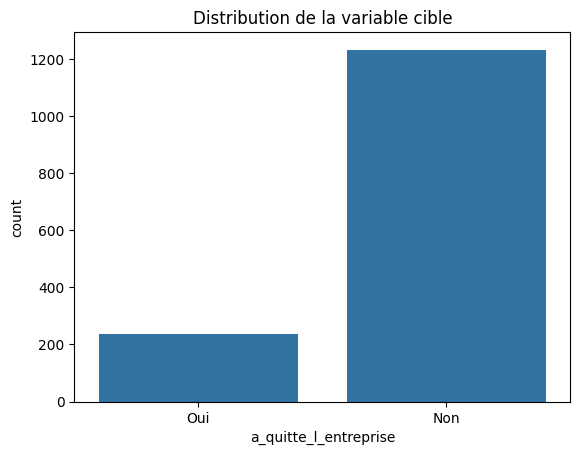

In [35]:
sns.countplot(x='a_quitte_l_entreprise', data=extrait)
plt.title("Distribution de la variable cible")
plt.show()

#### Quanti vs target

Nous observons un déséquilibre de classe, ayant beaucoup plus d'employés toujours dans l'entreprise (vs employés ayant quitté l'entreprise). Visualisons maintenant les liens entre les variables quantitatives et la target

In [36]:
extrait.groupby('a_quitte_l_entreprise')[col_quantitatives].mean().T

a_quitte_l_entreprise,Non,Oui
augmentation_salaire_precedente,15.231144,15.097046
age,37.561233,33.607595
revenu_mensuel,6832.739659,4787.092827
nombre_experiences_precedentes,2.645580,2.940928
annee_experience_totale,11.862936,8.244726
annees_dans_l_entreprise,7.369019,5.130802
annees_dans_le_poste_actuel,4.484185,2.902954
nombre_participation_pee,0.845093,0.527426
nb_formations_suivies,2.832928,2.624473
distance_domicile_travail,8.915653,10.632911


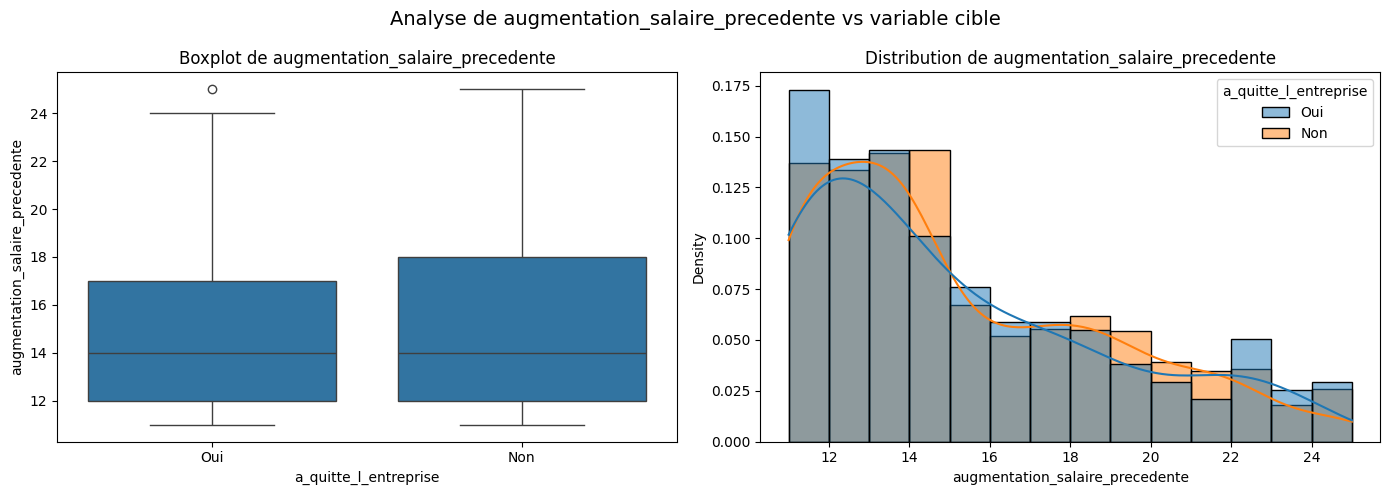

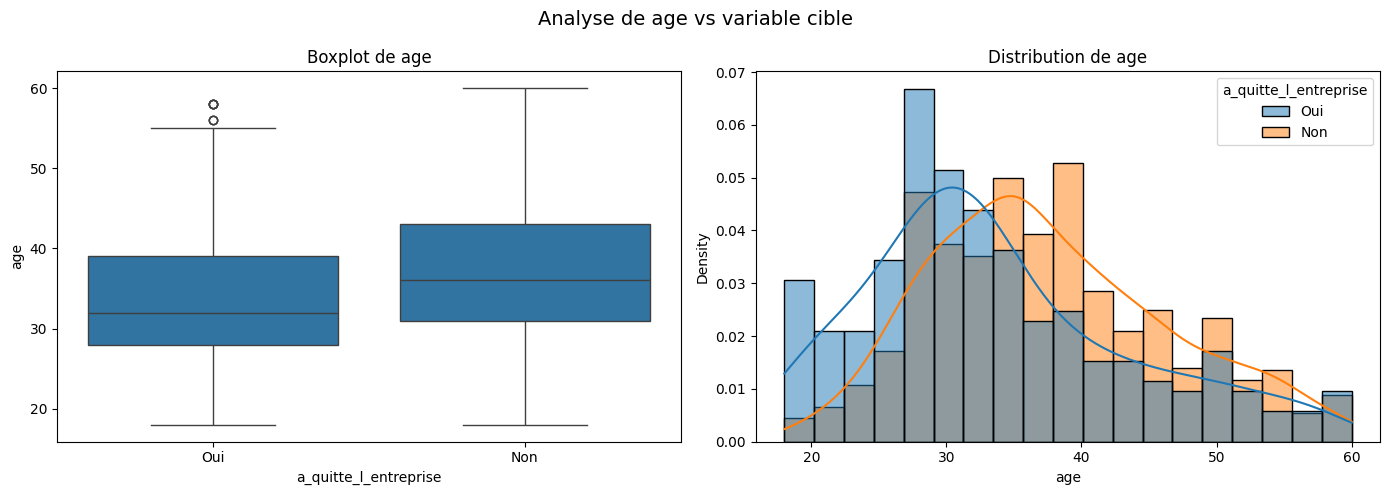

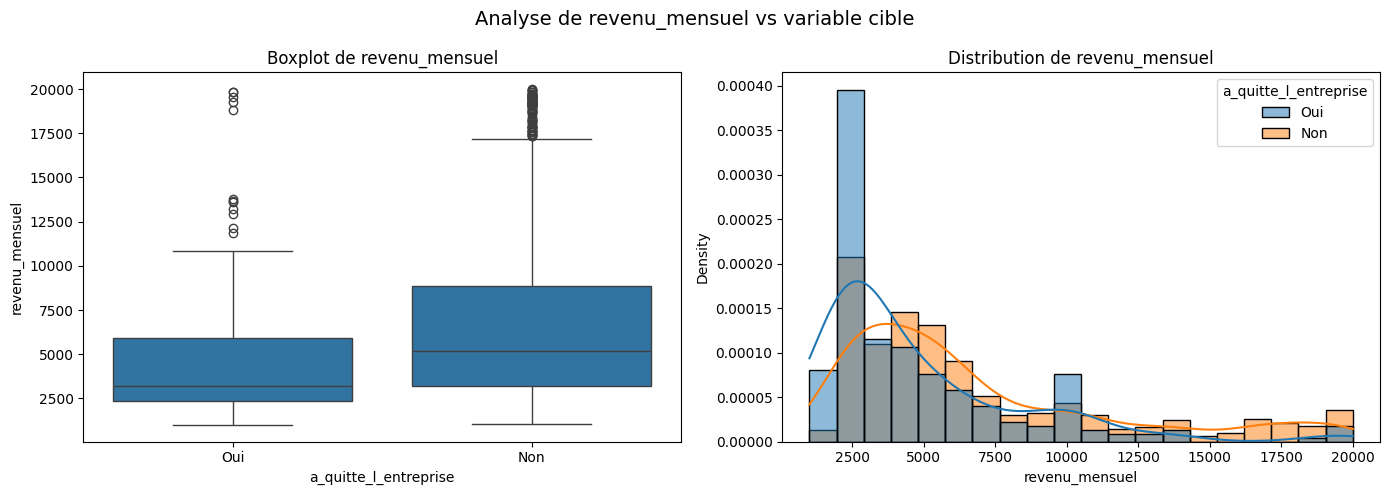

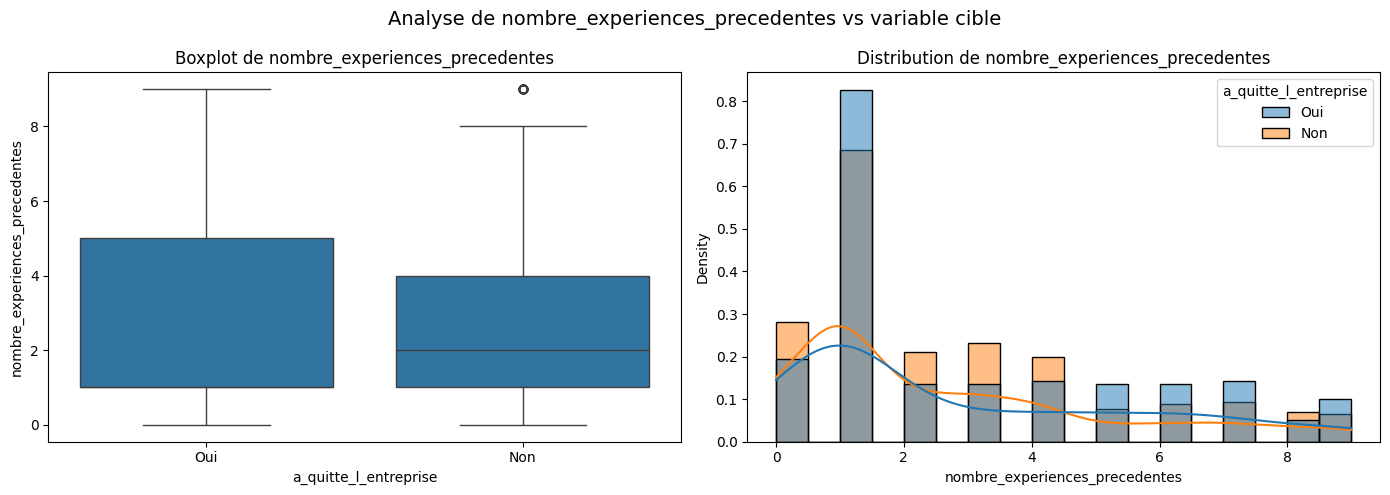

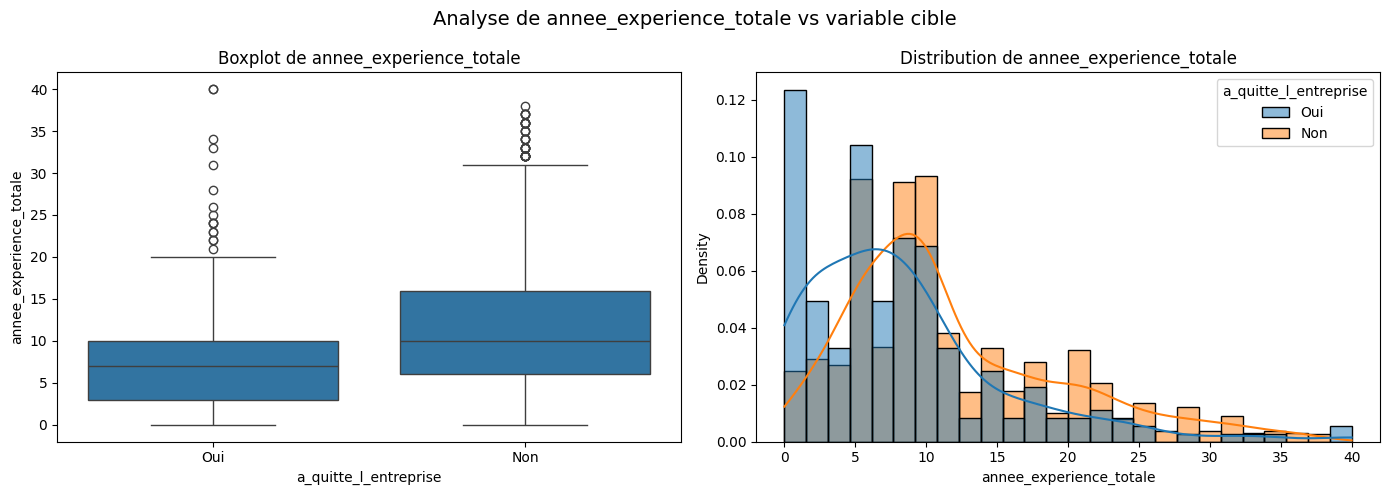

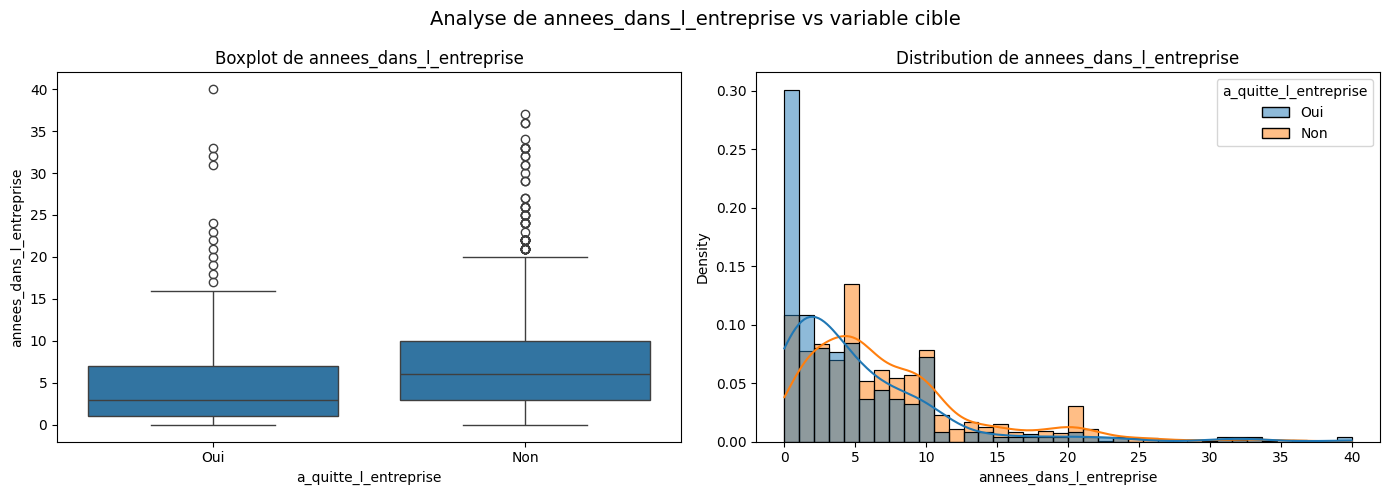

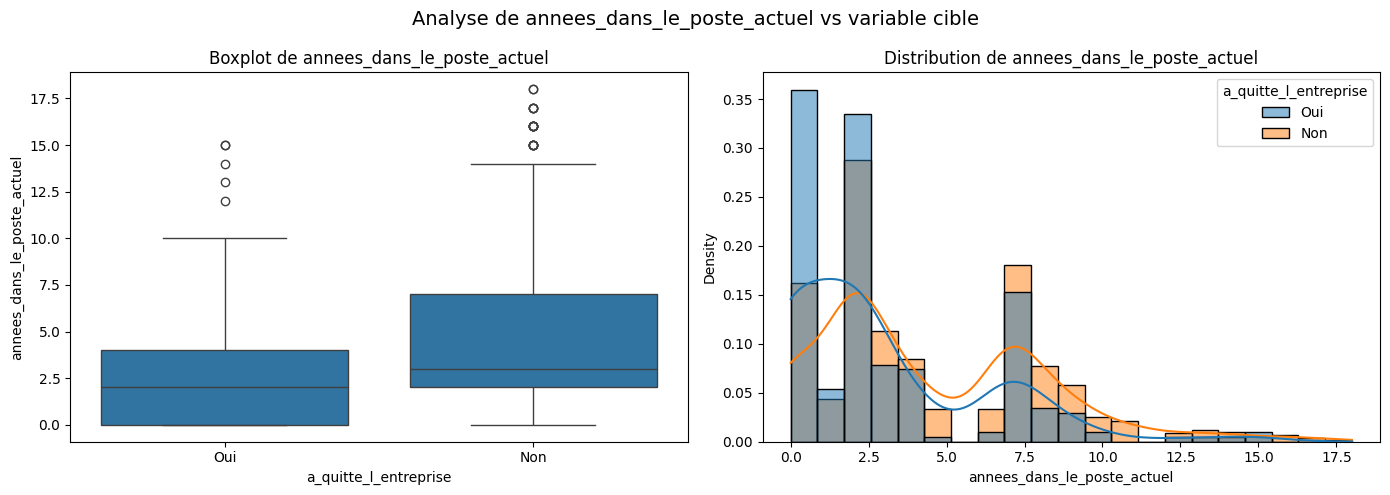

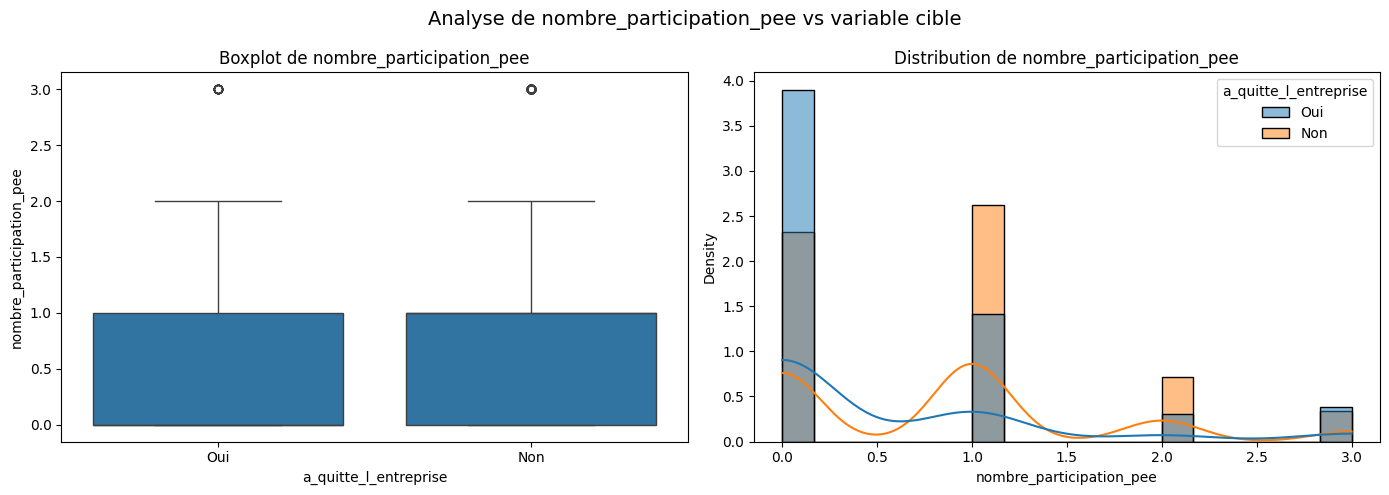

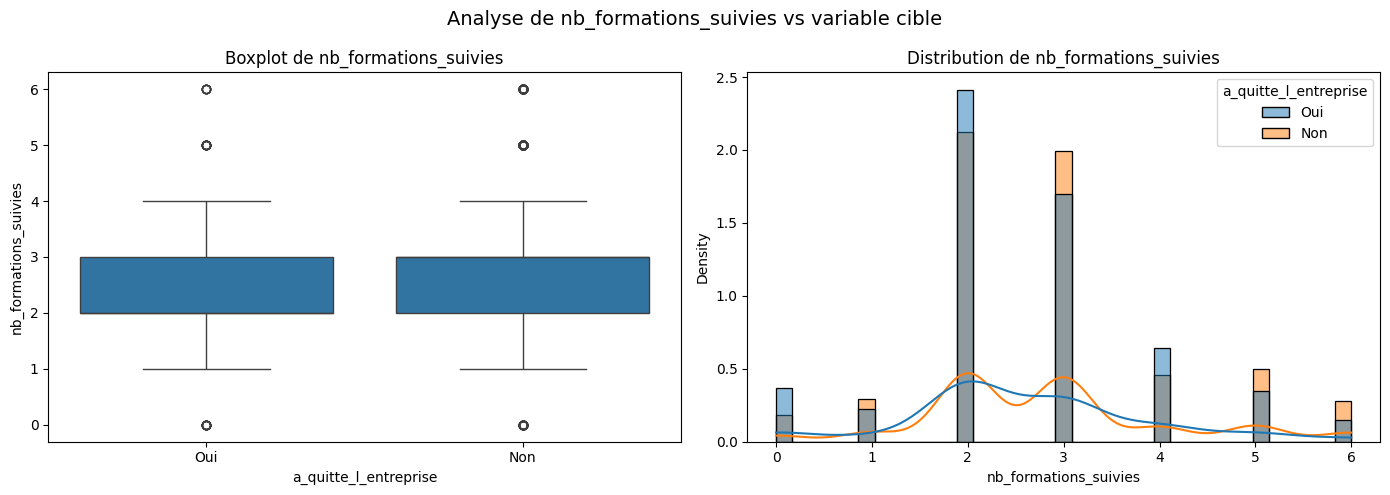

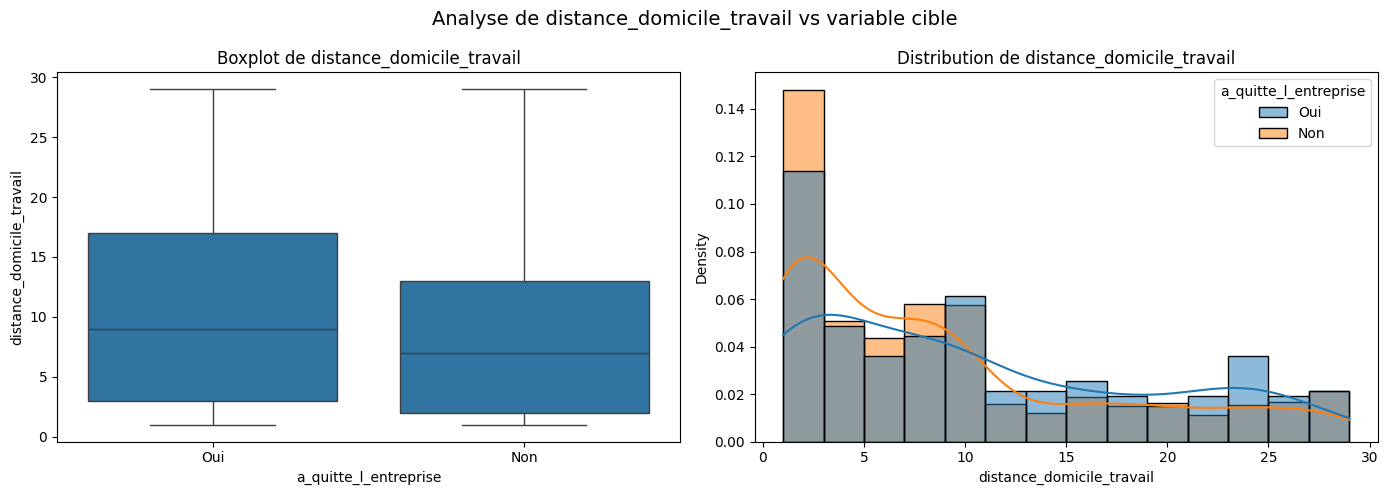

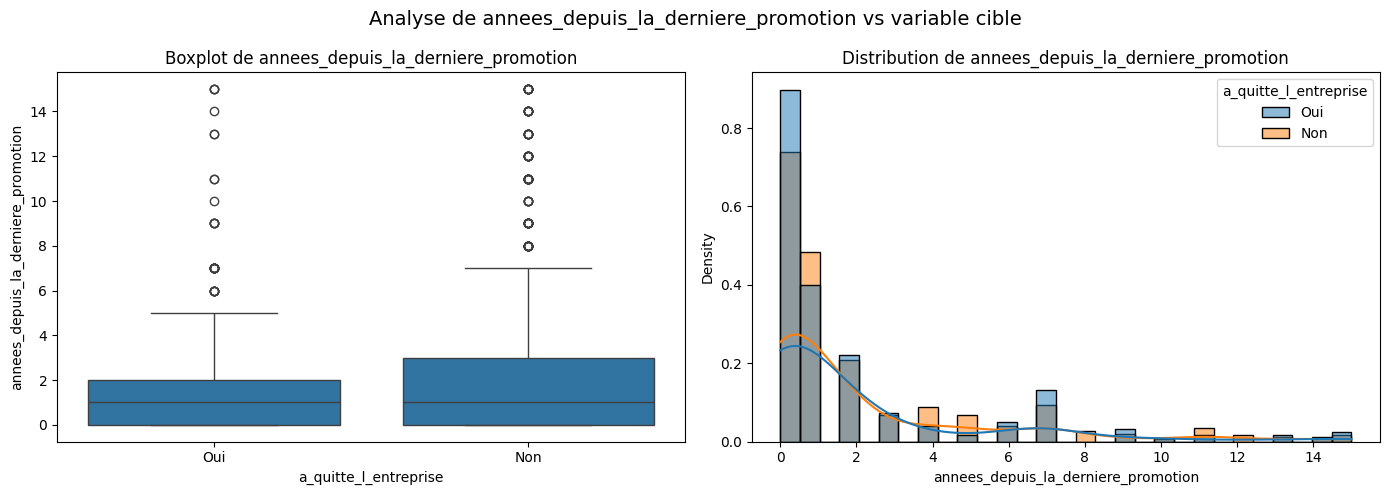

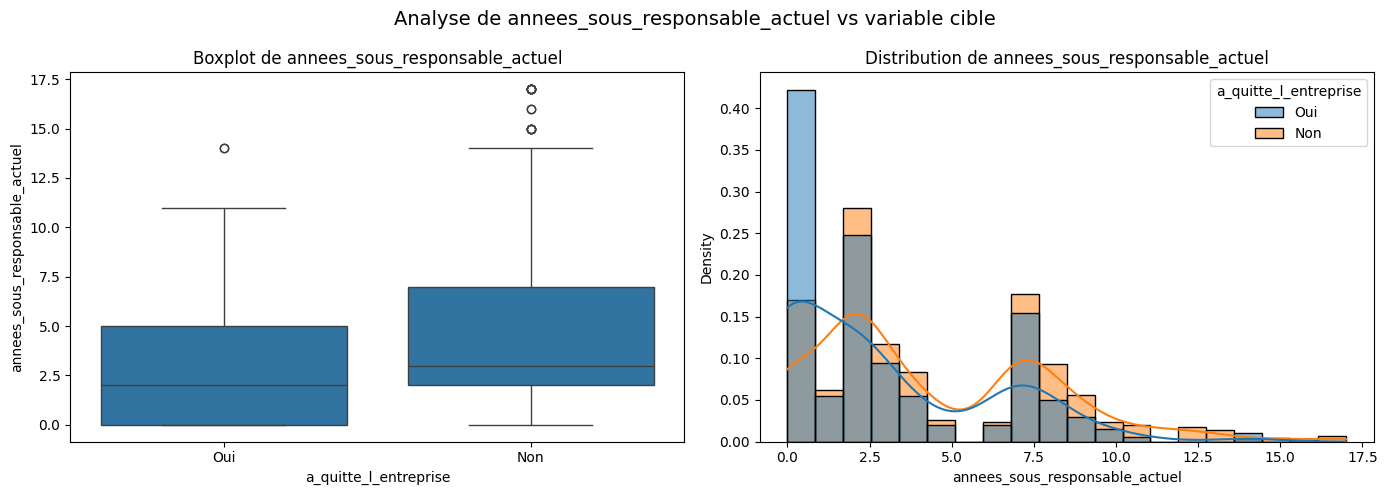

In [37]:
for col in col_quantitatives:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(
        x='a_quitte_l_entreprise', y=col, data=extrait, 
        ax=axes[0]
    )
    axes[0].set_title(f"Boxplot de {col}")
    
    sns.histplot(
        data=extrait, x=col, hue='a_quitte_l_entreprise',
        kde=True, stat='density', common_norm=False,
        ax=axes[1]
    )
    axes[1].set_title(f"Distribution de {col}")
    
    plt.suptitle(f"Analyse de {col} vs variable cible", fontsize=14)
    plt.tight_layout()
    plt.show()

Ces boxplots et histogrammes nous révèlent plusieurs enseignements :
- les jeunes ont tendance à partir plus souvent de l'entreprise (les courbes se croisent à 35 ans)
- les petits revenus ont tendance à partir plus souvent de l'entreprise (jusqu'à 2500€ mensuel)
- les personnes n'ayant qu'une expérience précédente ou plus de 5 expériences précédentes ont tendance à partir plus souvent de l'entreprise
- les personnes ayant moins de 8 ans d'expérience totale ont tendance à partir plus souvent de l'entreprise
- les personnes ayant moins de 1 an d'expérience dans l'entreprise ont une forte tendance à partir plus souvent de l'entreprise
- les personnes ayant moins de 2 ans et demi d'expérience sur leur poste actuel ont tendance à partir plus souvent de l'entreprise
- les personnes n'ayant pas de PEE ont tendance à partir plus souvent de l'entreprise
- les personnes habitant plus loin ont tendance à partir plus souvent de l'entreprise
- les personnes ayant moins de 1 an sous le responsable actuel ont tendance à partir plus souvent de l'entreprise

Relations moins claires (ou non linéaires) entre le fait de partir de l'entreprise et :
- le nombre d'années depuis la dernière promotion
- le nombre de formations suivies
- le nombre d'expériences précédentes
- l'augmentation vs salaire précédent

Certaines variables numériques sont probablement liées, avec l'age et le nombre d'années d'expérience totale, on peut s'attendre à ce que le revenu mensuel augmente.

Le nombre d'années dans l'entreprise est lié au nombre d'années dans le poste actuel (il est supérieur ou égal au nombre d'années dans le poste actuel)

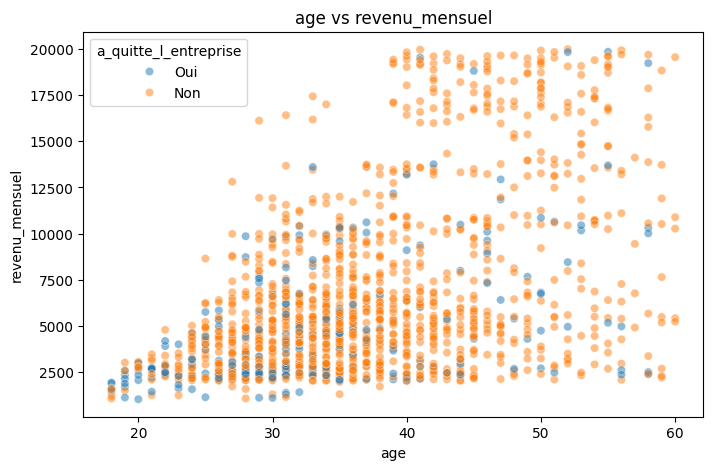

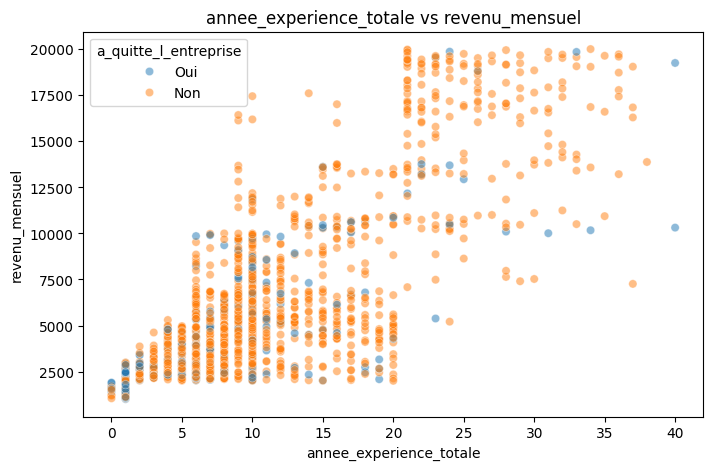

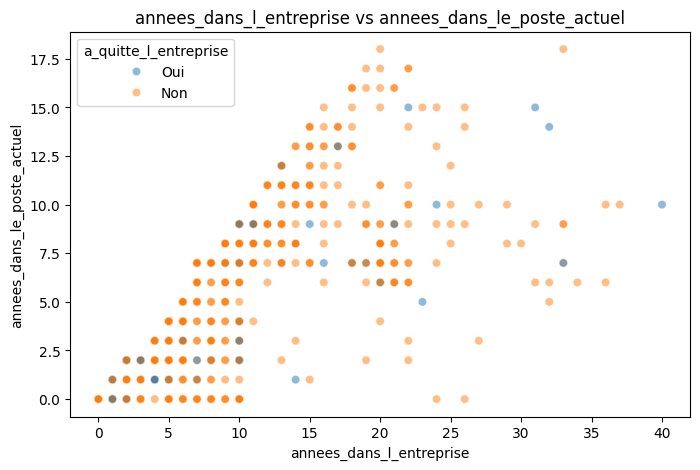

In [38]:
paires = [
    ('age', 'revenu_mensuel'),
    ('annee_experience_totale', 'revenu_mensuel'),
    ('annees_dans_l_entreprise', 'annees_dans_le_poste_actuel'),
]

for x_col, y_col in paires:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=extrait, x=x_col, y=y_col, 
                    hue='a_quitte_l_entreprise', alpha=0.5)
    plt.title(f"{x_col} vs {y_col}")
    plt.show()

On observe bien ces liens via les scatterplots ci-dessus. La liaison avec le fait de quitter l'entreprise ou non est néanmoins difficile à lire sur ces scatterplots (beaucoup plus claire sur les boxplot et histogrammes du dessus)

#### Quali ordinales vs target

Les colonnes ordinales sont toutes chiffrées, excepté `frequence_deplacement`. Nous allons donc l'encoder

In [39]:
extrait['frequence_deplacement'].value_counts()

frequence_deplacement
Occasionnel    1043
Frequent        277
Aucun           150
Name: count, dtype: int64

In [40]:
encoder = OrdinalEncoder(
    categories=[["Aucun", "Occasionnel", "Frequent"]]
)
extrait[['frequence_deplacement']] = encoder.fit_transform(
    extrait[['frequence_deplacement']]
)

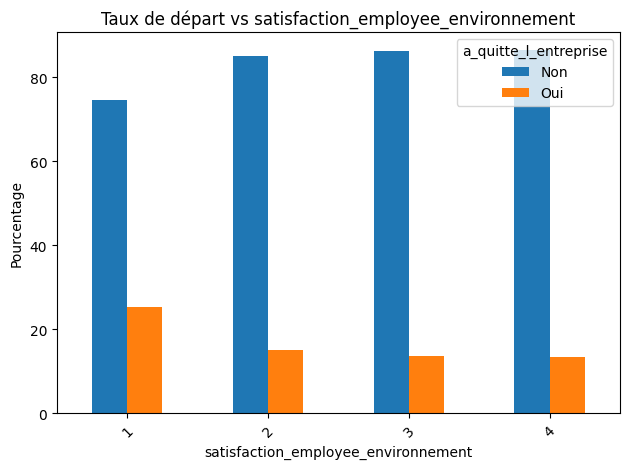

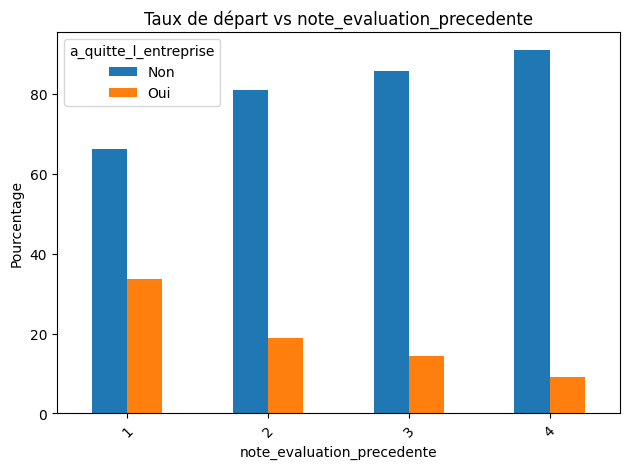

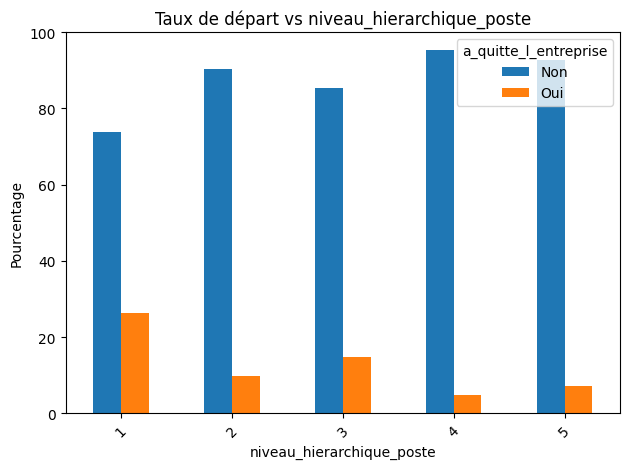

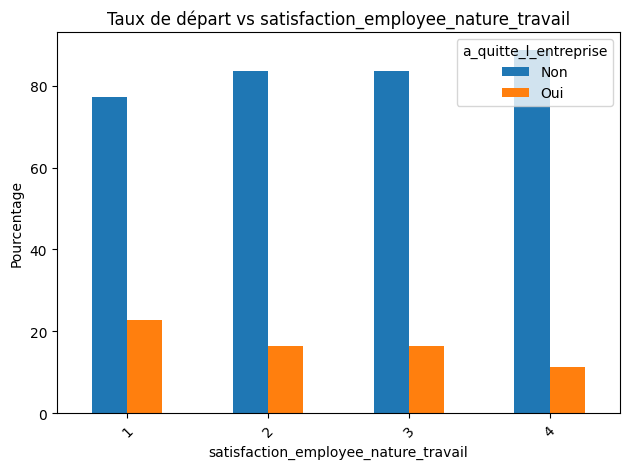

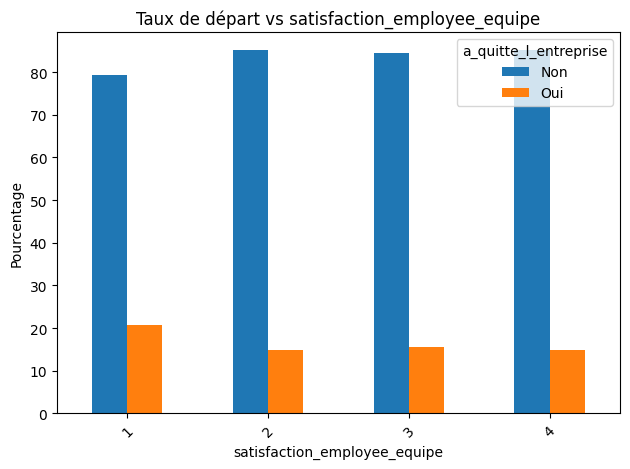

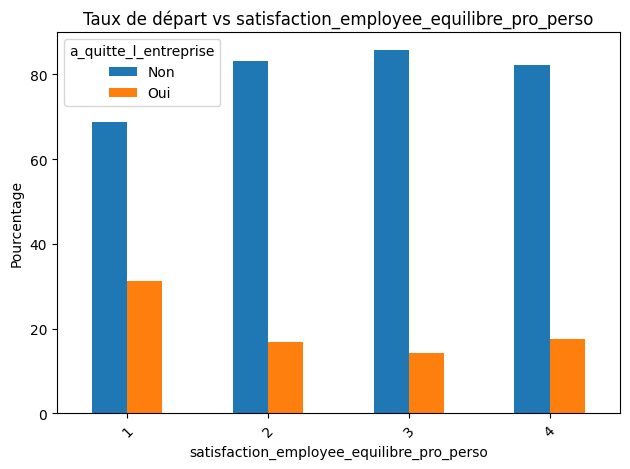

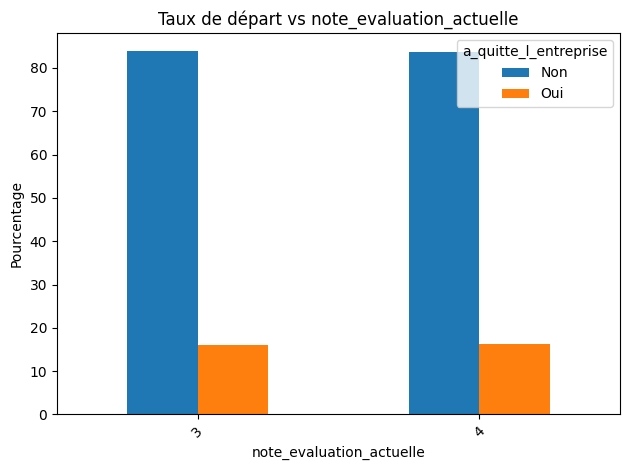

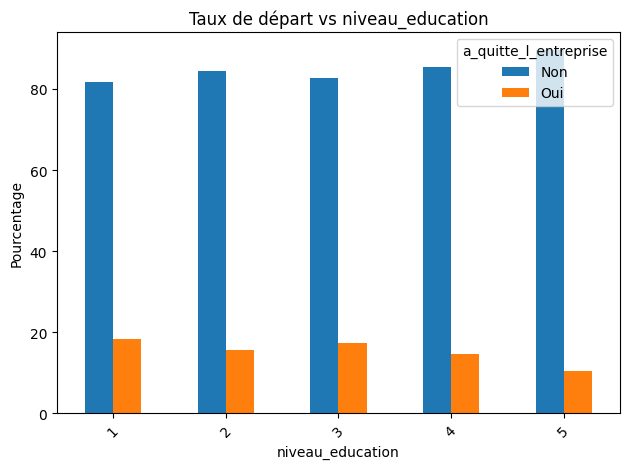

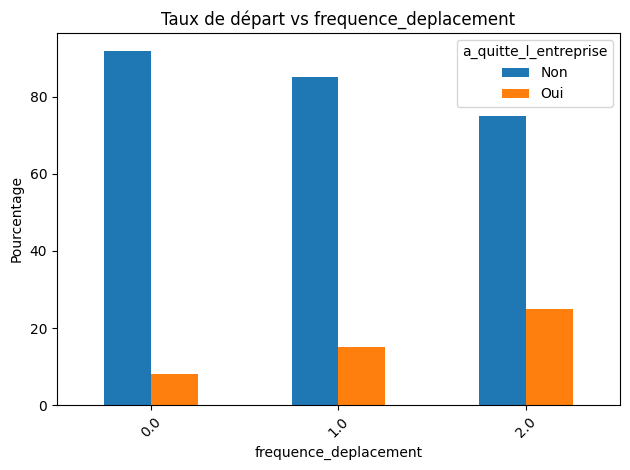

In [41]:
for col in col_qualitatives_ordinales:
    pourcentages = pd.crosstab(
        extrait[col],
        extrait['a_quitte_l_entreprise'],
        normalize='index'
    ) * 100

    pourcentages.plot(kind='bar')

    plt.title(f"Taux de départ vs {col}")
    plt.ylabel("Pourcentage")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Ces plots nous révèlent des informations intéressants, avec des taux de départs plus important lorsque ;
- `satisfaction_employee_environnement` est faible
- `note_evaluation_precedente` est faible
- `niveau_hierarchique_poste` est faible
- `satisfaction_employee_nature_travail` est faible
- `satisfaction_employee_equipe` est faible
- `satisfaction_employee_equilibre_pro_perso` est faible
- `niveau_education` est faible
- `frequence_deplacement` est important

La seule variable sans lien évident est `note_evaluation_actuelle`

#### Quali nominales vs target

Regardons maintenant les colonnes qualitatives nominales vs la target

<Figure size 1000x500 with 0 Axes>

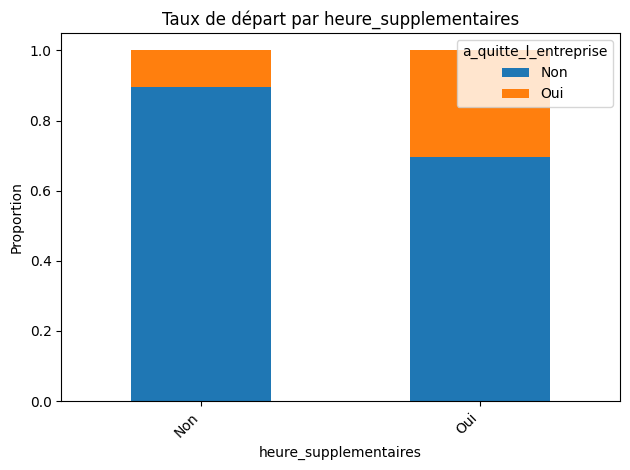

<Figure size 1000x500 with 0 Axes>

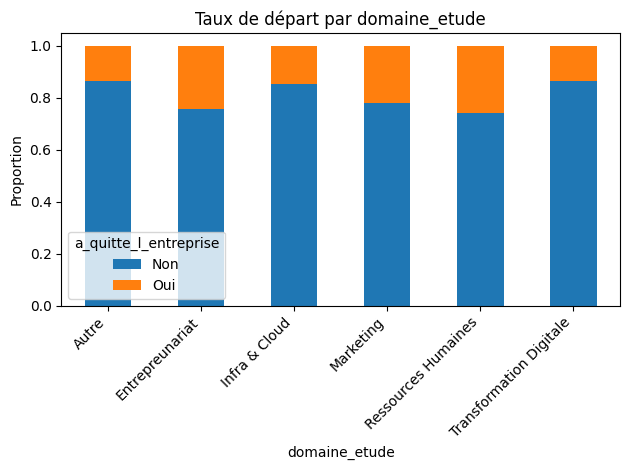

<Figure size 1000x500 with 0 Axes>

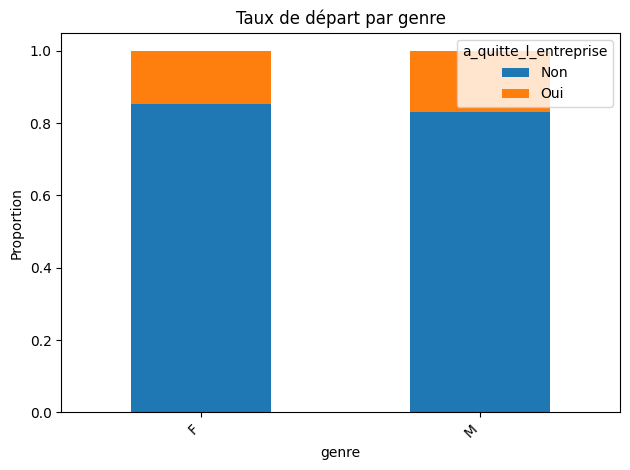

<Figure size 1000x500 with 0 Axes>

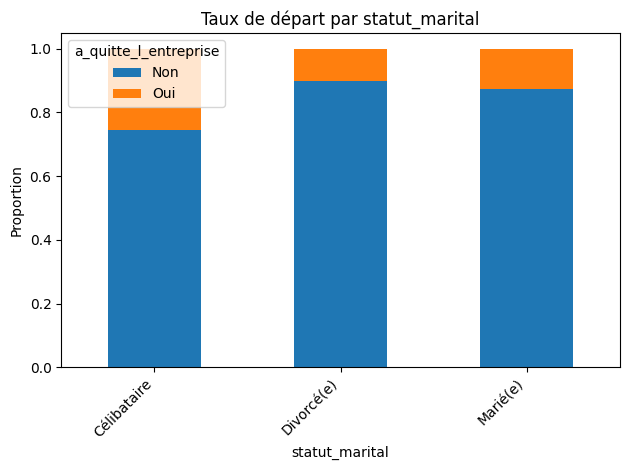

<Figure size 1000x500 with 0 Axes>

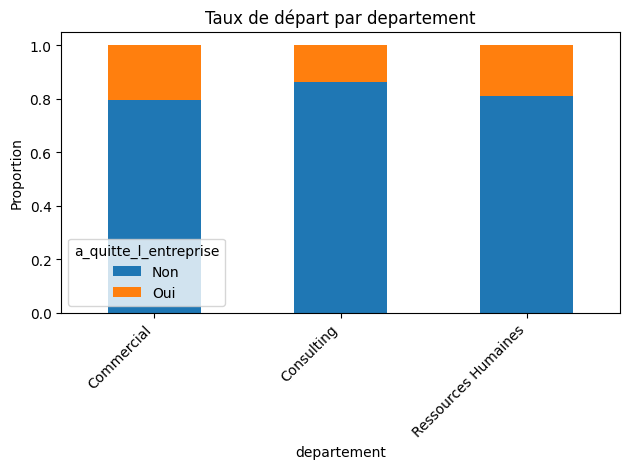

<Figure size 1000x500 with 0 Axes>

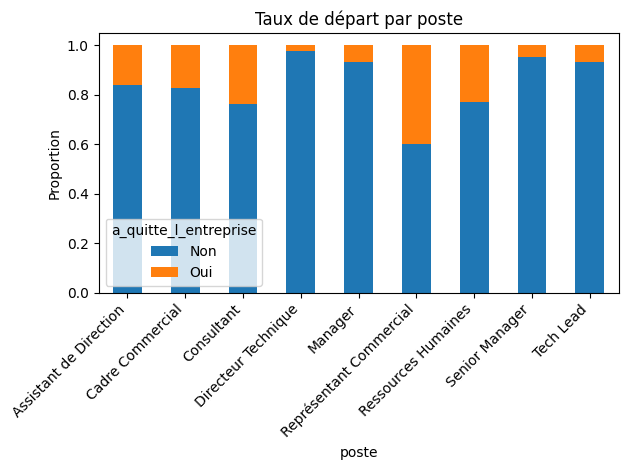

In [42]:
for col in col_qualitatives_nominales:
    plt.figure(figsize=(10, 5))
    ct = pd.crosstab(extrait[col], extrait['a_quitte_l_entreprise'])
    proportions = ct.div(ct.sum(axis=1), axis=0)
    proportions.plot(kind='bar', stacked=True)
    plt.title(f"Taux de départ par {col}")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Ces barplots nous révèlent également des distributions différentes des variables qualitatives nominales vs notre target. Seul le sexe ne parait pas avoir de rapport évident. On note en particulier ;
- beaucoup de départs sur le poste Représentant Commercial, 40%
- un taux de départ plus fort dans les départements Commercial & Ressources Humaines
- les célibataires partent plus, environ 25% (vs environ 10% pour les personnes mariées ou divorcées)
- départs également plus fréquents chez les personnes ayant étudiées les Ressources Humaines
- départs également bien plus fréquents chez les personnes ayant pris des heures supplémentaires (environ 30% de départ vs environ 10% pour ceux n'en ayant pas pris)

Le plus marquant ; Représentant Commercial et personnes ayant pris des heures supplementaires

# 2. Préparation de la donnée

### Import des modules

In [43]:

from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

Commençons par encoder la target

In [44]:
extrait['a_quitte_l_entreprise'] = extrait['a_quitte_l_entreprise'].map({
    'Oui': 1, 'Non': 0
})

### Corrélations linéaires entre variables quantitatives & qualitatives ordinales

Définissons une fonction pour tracer les heatmap de corrélations

In [45]:
def plot_correlation_heatmap(df, columns, method='spearman', figsize=(12,10)):
    mat_corr=df[columns].corr(method=method)
    plt.figure(figsize=figsize)
    sns.heatmap(mat_corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title(f'Matrice de corrélation ({method})')
    plt.show()
    return mat_corr

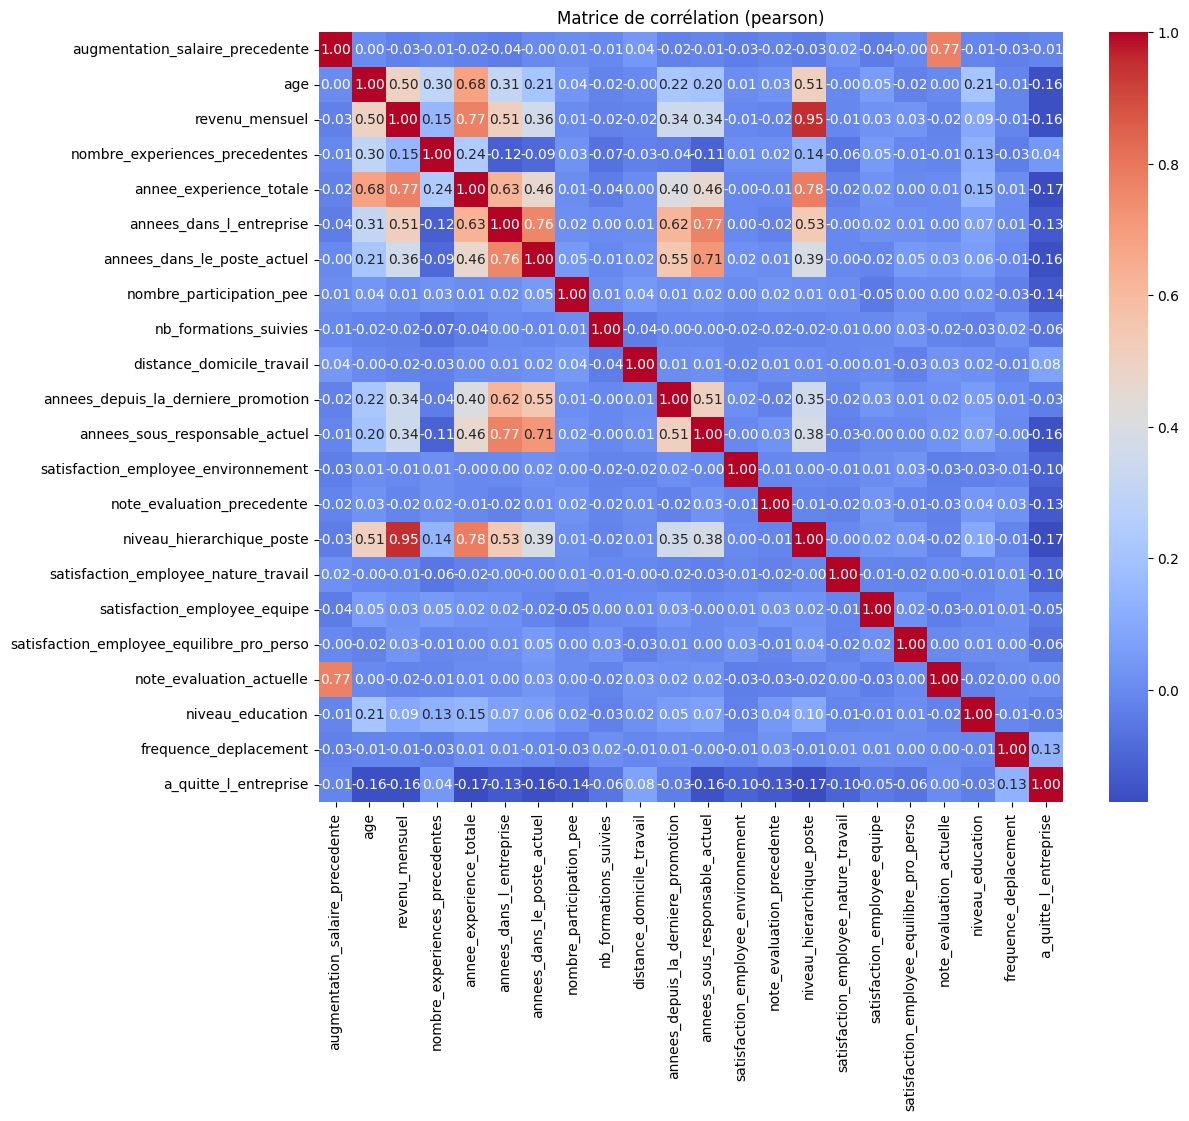

,augmentation_salaire_precedente,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,niveau_education,frequence_deplacement,a_quitte_l_entreprise
augmentation_salaire_precedente,1.000000,0.003634,-0.027269,-0.010238,-0.020608,-0.035991,-0.001520,0.007528,-0.005221,0.040235,-0.022154,-0.011985,-0.031701,-0.017205,-0.034730,0.020002,-0.040490,-0.003280,0.773550,-0.011111,-0.025727,-0.013478
age,0.003634,1.000000,0.497855,0.299635,0.680381,0.311309,0.212901,0.037510,-0.019621,-0.001686,0.216513,0.202089,0.010146,0.029820,0.509604,-0.004892,0.053535,-0.021490,0.001904,0.208034,-0.011807,-0.159205
revenu_mensuel,-0.027269,0.497855,1.000000,0.149515,0.772893,0.514285,0.363818,0.005408,-0.021736,-0.017014,0.344978,0.344079,-0.006259,-0.015271,0.950300,-0.007157,0.025873,0.030683,-0.017120,0.094961,-0.013450,-0.159840
nombre_experiences_precedentes,-0.010238,0.299635,0.149515,1.000000,0.237639,-0.118421,-0.090754,0.030075,-0.066054,-0.029251,-0.036814,-0.110319,0.012594,0.015012,0.142501,-0.055699,0.052733,-0.008366,-0.014095,0.126317,-0.030743,0.043494
annee_experience_totale,-0.020608,0.680381,0.772893,0.237639,1.000000,0.628133,0.460365,0.010136,-0.035662,0.004628,0.404858,0.459188,-0.002693,-0.005533,0.782208,-0.020185,0.024054,0.001008,0.006744,0.148280,0.007972,-0.171063
annees_dans_l_entreprise,-0.035991,0.311309,0.514285,-0.118421,0.628133,1.000000,0.758754,0.015058,0.003569,0.009508,0.618409,0.769212,0.001458,-0.021355,0.534739,-0.003803,0.019367,0.012089,0.003435,0.069114,0.005212,-0.134392
annees_dans_le_poste_actuel,-0.001520,0.212901,0.363818,-0.090754,0.460365,0.758754,1.000000,0.050818,-0.005738,0.018845,0.548056,0.714365,0.018007,0.008717,0.389447,-0.002305,-0.015123,0.049856,0.034986,0.060236,-0.005336,-0.160545
nombre_participation_pee,0.007528,0.037510,0.005408,0.030075,0.010136,0.015058,0.050818,1.000000,0.011274,0.044872,0.014352,0.024698,0.003432,0.021523,0.013984,0.010690,-0.045952,0.004129,0.003506,0.018422,-0.028257,-0.137145
nb_formations_suivies,-0.005221,-0.019621,-0.021736,-0.066054,-0.035662,0.003569,-0.005738,0.011274,1.000000,-0.036942,-0.002067,-0.004096,-0.019359,-0.015338,-0.018191,-0.005779,0.002497,0.028072,-0.015579,-0.025100,0.016357,-0.059478
distance_domicile_travail,0.040235,-0.001686,-0.017014,-0.029251,0.004628,0.009508,0.018845,0.044872,-0.036942,1.000000,0.010029,0.014406,-0.016075,0.008783,0.005303,-0.003669,0.006557,-0.026556,0.027110,0.021042,-0.009696,0.077924


In [46]:
plot_correlation_heatmap(extrait, col_quantitatives + col_qualitatives_ordinales + [target], method='pearson')

Nous allons maintenant coder une fonction pour lister les features redondantes (pearson > 0.7)

In [47]:
def lister_features_correlees(df, seuil=0.7):
    """Liste les paires de features corrélées au-dessus du seuil."""
    corr_matrix = df.corr(method='pearson').abs()
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    paires = []
    for col in upper_tri.columns:
        for idx in upper_tri.index:
            val = upper_tri.loc[idx, col]
            if val > seuil:
                paires.append((idx, col, round(val, 2)))
    
    return paires

In [48]:
paires = lister_features_correlees(
    extrait[col_quantitatives + col_qualitatives_ordinales]
)

for f1, f2, corr in paires:
    print(f"{f1}  ↔  {f2}  :  {corr}")

revenu_mensuel  ↔  annee_experience_totale  :  0.77
annees_dans_l_entreprise  ↔  annees_dans_le_poste_actuel  :  0.76
annees_dans_l_entreprise  ↔  annees_sous_responsable_actuel  :  0.77
annees_dans_le_poste_actuel  ↔  annees_sous_responsable_actuel  :  0.71
revenu_mensuel  ↔  niveau_hierarchique_poste  :  0.95
annee_experience_totale  ↔  niveau_hierarchique_poste  :  0.78
augmentation_salaire_precedente  ↔  note_evaluation_actuelle  :  0.77


Quelles variables conserver ?
- On a un bloc "Carrière" avec `revenu_mensuel` <-> `annee_experience_totale` `<-> niveau_hierarchique_poste`. On va conserver `revenu_mensuel` car l'équipe RH peut agir plus facilement dessus, et `niveau_hierarchique` a une corrélation quasi parfaite avec `revenu` (0.95)
- On a un bloc "Ancienneté" avec `annees_dans_l_entreprise` <-> `annees_dans_le_poste_actuel` <-> `annees_sous_responsable_actuel`. On va conserver `annees_dans_l_entreprise` car c'est la variable la plus "englobante", on avait également noté le fort taux de départ la première année
- On a un bloc "Evaluation" avec `augmentation_salaire_precedente` <-> `note_evaluation_actuelle`. On va conserver note_evaluation actuelle, ils ont tous les 2 sensiblement la même corrélation avec la cible, mais la note est la cause principale de l'augmentation de salaire, donc autant conserver la cause plutôt que la conséquence

In [49]:
extrait.shape

(1470, 29)

In [50]:
extrait = extrait.drop(columns=['niveau_hierarchique_poste', 'annee_experience_totale',
                                'annees_dans_le_poste_actuel', 'annees_sous_responsable_actuel',
                                'augmentation_salaire_precedente'])
extrait.shape

(1470, 24)

In [51]:
colonnes_a_supprimer = [
    'annee_experience_totale',
    'annees_dans_le_poste_actuel',
    'annees_sous_responsable_actuel',
    'augmentation_salaire_precedente'
]

col_quantitatives = [
    col for col in col_quantitatives
    if col not in colonnes_a_supprimer
]

In [52]:
col_qualitatives_ordinales = [col for col in col_qualitatives_ordinales if col != 'niveau_hierarchique_poste']

### Corrélations non-linéaires entre variables quantitatives / qualitatives ordinales

Visualisons les corrélations non-linéaires éventuelles sur quelques variables clés

In [53]:
cols_pairplot = [
    'revenu_mensuel',
    'age',
    'annees_dans_l_entreprise',
    'distance_domicile_travail'
]

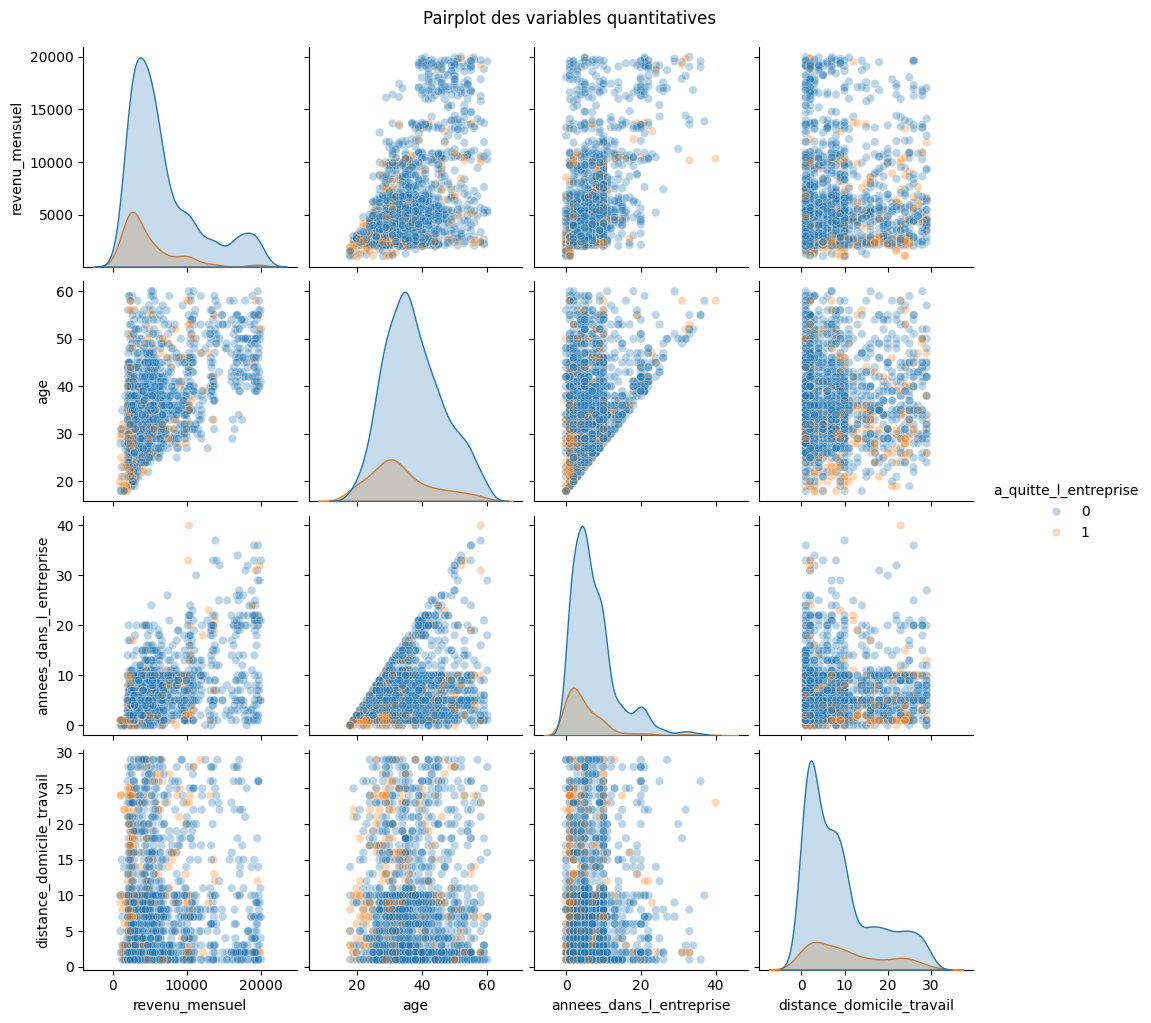

In [54]:
sns.pairplot(
    extrait[cols_pairplot + ['a_quitte_l_entreprise']],
    hue='a_quitte_l_entreprise',
    diag_kind='kde',
    plot_kws={'alpha': 0.3}
)
plt.suptitle("Pairplot des variables quantitatives", y=1.02)
plt.show()

Observations du pairplot :
- Le pairplot confirme les corrélations linéaires déjà identifiées 
  par Pearson (age × revenu, age × ancienneté)
- Aucune relation non-linéaire marquante n'est visible entre 
  les variables quantitatives

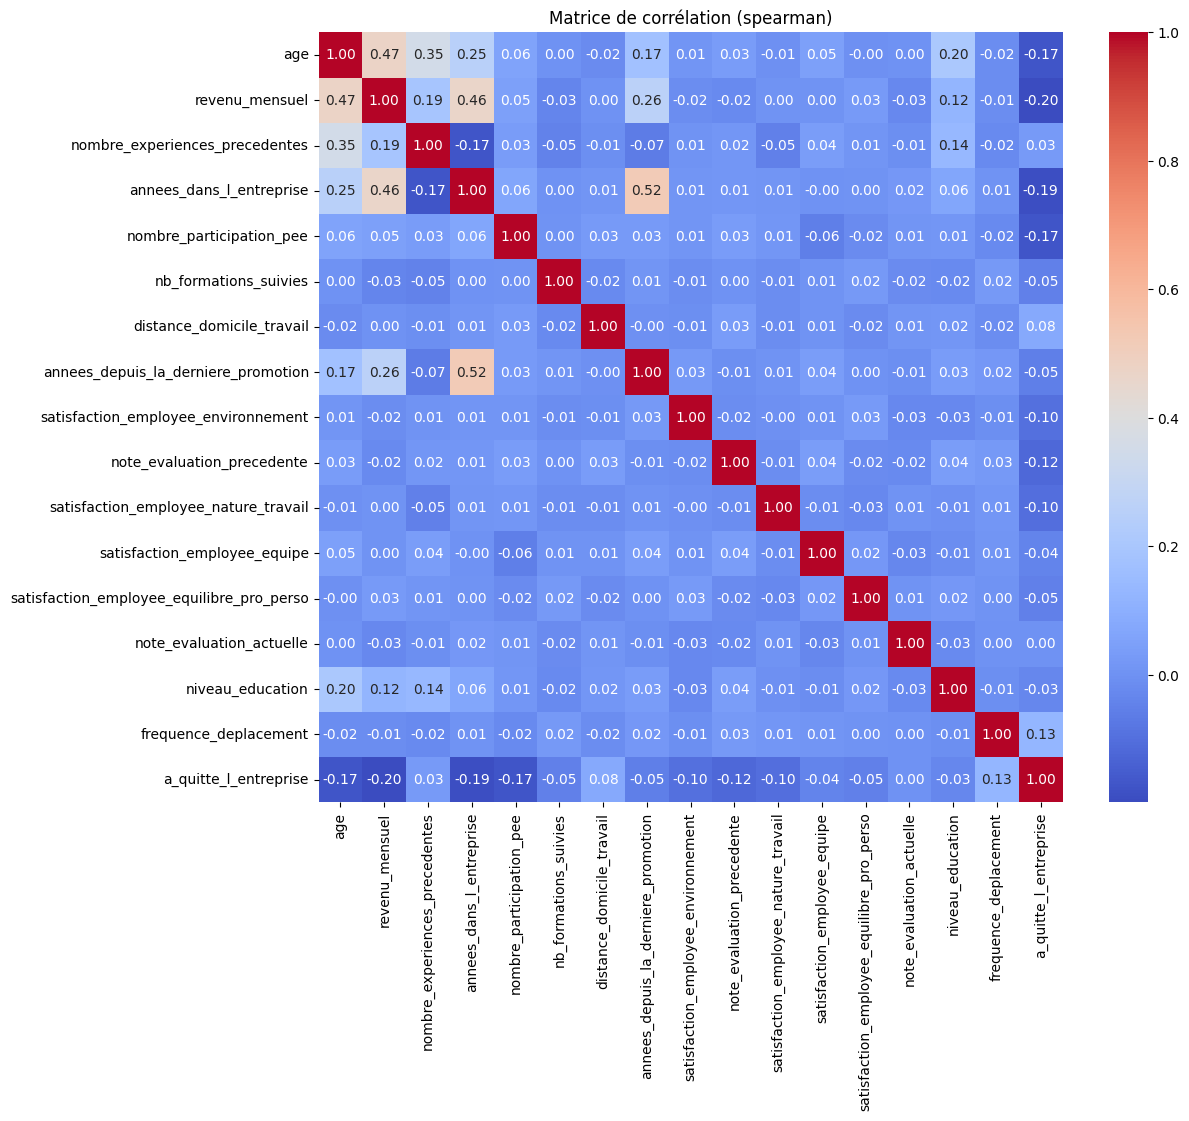

,age,revenu_mensuel,nombre_experiences_precedentes,annees_dans_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,annees_depuis_la_derniere_promotion,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,niveau_education,frequence_deplacement,a_quitte_l_entreprise
age,1.000000,0.471902,0.353213,0.251686,0.056633,0.000316,-0.019291,0.173647,0.009820,0.034456,-0.005185,0.046063,-0.003707,0.000093,0.204937,-0.015747,-0.171214
revenu_mensuel,0.471902,1.000000,0.190307,0.464315,0.045852,-0.034847,0.002512,0.264599,-0.015163,-0.024552,0.004881,0.003885,0.030759,-0.026999,0.120028,-0.012614,-0.198305
nombre_experiences_precedentes,0.353213,0.190307,1.000000,-0.171070,0.032277,-0.047336,-0.009592,-0.066950,0.006151,0.015448,-0.051516,0.040296,0.009103,-0.008298,0.135103,-0.024186,0.030505
annees_dans_l_entreprise,0.251686,0.464315,-0.171070,1.000000,0.064974,0.001389,0.010513,0.519966,0.008425,0.013836,0.012280,-0.001267,0.004675,0.017224,0.064196,0.006695,-0.190419
nombre_participation_pee,0.056633,0.045852,0.032277,0.064974,1.000000,0.003388,0.030190,0.027502,0.009826,0.034464,0.012785,-0.056249,-0.016568,0.011028,0.013794,-0.023209,-0.172296
nb_formations_suivies,0.000316,-0.034847,-0.047336,0.001389,0.003388,1.000000,-0.024848,0.010215,-0.011659,0.002014,-0.011681,0.005424,0.023690,-0.016676,-0.023749,0.023921,-0.051757
distance_domicile_travail,-0.019291,0.002512,-0.009592,0.010513,0.030190,-0.024848,1.000000,-0.004685,-0.010401,0.034430,-0.013078,0.005852,-0.020402,0.011320,0.015708,-0.015428,0.079248
annees_depuis_la_derniere_promotion,0.173647,0.264599,-0.066950,0.519966,0.027502,0.010215,-0.004685,1.000000,0.026082,-0.008307,0.007497,0.036963,0.002151,-0.006578,0.032203,0.021037,-0.053273
satisfaction_employee_environnement,0.009820,-0.015163,0.006151,0.008425,0.009826,-0.011659,-0.010401,0.026082,1.000000,-0.015301,-0.002993,0.005353,0.027169,-0.029160,-0.027625,-0.009586,-0.096486
note_evaluation_precedente,0.034456,-0.024552,0.015448,0.013836,0.034464,0.002014,0.034430,-0.008307,-0.015301,1.000000,-0.012148,0.037857,-0.019889,-0.024733,0.037231,0.025005,-0.119496


In [55]:
plot_correlation_heatmap(extrait, col_quantitatives + col_qualitatives_ordinales + [target], method='spearman')

Rien de nouveau par rapport à la matrice de Pearson précédente, il n'y pas de corrélation monotone que l'on aurait loupé précédemment.

### Corrélations entre variables qualitatives

Regardons maintenant la corrélation des variables qualitatives entre elles, on va tout d'abord créer une fonction pour calculer le Chi-2 et la valeur de Cramer associée

In [56]:
def chi2_test(df, col1, col2):
    """Test du Chi-2 entre deux variables qualitatives + V de Cramér."""
    contingence = pd.crosstab(df[col1], df[col2])
    chi2, pvalue, dof, expected = chi2_contingency(contingence)
    
    # V de Cramér : version normalisée du Chi-2 (entre 0 et 1)
    n = contingence.sum().sum()
    k = min(contingence.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * k))
    
    return v_cramer, pvalue

On souhaite maintenant calculer le V de Cramer pour chaque paire de variables qualitatives afin de détecter les redondances potentielles. On visualisera cela dans une heatmap, en cachant les paires non significatives

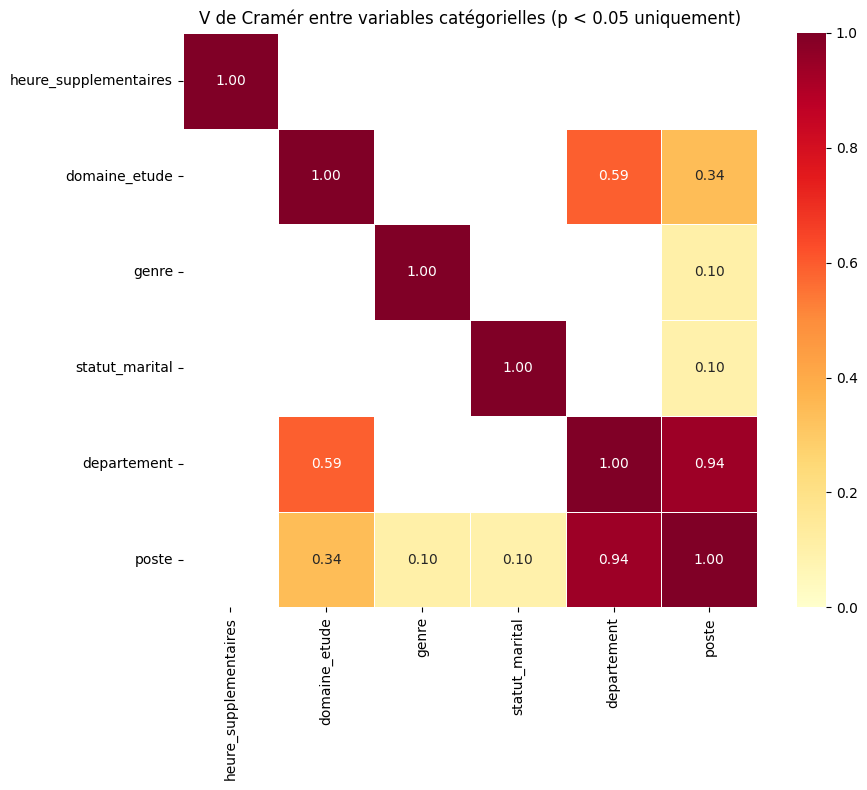

In [57]:
# --- Construire les matrices ---
n = len(col_qualitatives_nominales)
cramer_matrix = pd.DataFrame(np.zeros((n, n)), index=col_qualitatives_nominales, columns=col_qualitatives_nominales)
pvalue_matrix = pd.DataFrame(np.ones((n, n)),  index=col_qualitatives_nominales, columns=col_qualitatives_nominales)

for i in range(n):
    for j in range(i + 1, n):
        v, p = chi2_test(extrait, col_qualitatives_nominales[i], col_qualitatives_nominales[j])
        cramer_matrix.iloc[i, j] = v
        cramer_matrix.iloc[j, i] = v
        pvalue_matrix.iloc[i, j] = p
        pvalue_matrix.iloc[j, i] = p
    cramer_matrix.iloc[i, i] = 1.0

# --- Masquer les paires non significatives ---
SEUIL_P = 0.05
cramer_display = cramer_matrix.where(pvalue_matrix < SEUIL_P)
for i in range(n):
    cramer_display.iloc[i, i] = 1.0

# --- Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramer_display,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    mask=cramer_display.isna(),
    linewidths=0.5, square=True
)
plt.title("V de Cramér entre variables catégorielles (p < 0.05 uniquement)")
plt.tight_layout()
plt.show()

On observe une corrélation très forte entre le `département` et le `poste` (0.94), supprimons `département` car l'information de `poste` est plus granulaire

In [58]:
extrait = extrait.drop(columns=['departement'])
extrait.shape

(1470, 23)

In [59]:
col_qualitatives_nominales = [col for col in col_qualitatives_nominales if col != 'departement']

### Encoder les variables qualitatives nominales, préparer X et y

Regardons de quoi sont faites nos variables qualitatives nominales (NB : `frequence_deplacement` est déjà une colonne numérique, nous l'avons encodé précédemment)

In [60]:
metadata_extrait(extrait[col_qualitatives_nominales])

,colonne,type,nb_unique,pct_manquant,min,max,avg
0,heure_supplementaires,str,2,0.0,-,-,-
1,domaine_etude,str,6,0.0,-,-,-
2,genre,str,2,0.0,-,-,-
3,statut_marital,str,3,0.0,-,-,-
4,poste,str,9,0.0,-,-,-


Nous pouvons partir sur un OneHotEncoder pour toutes les variables (binaires incluses). Les variables binaires auraient pu être encodées avec un simple OrdinalEncoder puisqu'avec 2 catégories, la question de l'ordre ne se pose pas — le résultat est identique. J'ai préféré utiliser OneHotEncoder pour l'ensemble des nominales pour simplifier le code. 

J'ai également utilisé un StandardScaler pour les variables numériques, ce sera utile pour les modèles où les distances sont importantes, type régression logistique

J'ai stratifié le split sur y pour préserver la proportion 84/16 entre train et test, garantissant des métriques comparables.

In [61]:
y = extrait['a_quitte_l_entreprise']
X = extrait.drop(columns=['a_quitte_l_entreprise', 'id_employe'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cols_numeriques = [col for col in X.columns 
                   if col not in col_qualitatives_nominales]

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), 
     col_qualitatives_nominales),
    ('num', Pipeline([
        ('scaler', StandardScaler())
        ]), cols_numeriques),
])

# 3. Premier modèle de classification

### Import des modules

In [62]:

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score, fbeta_score

### Entrainement et évaluation des premiers modèles

Nous allons entrainer un modèle Dummy, une régression logistique et deux modèles à base d'arbres, LightGBM et un RandomForestClassifier.

In [63]:
pipelines = {
    'Dummy': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DummyClassifier(strategy='most_frequent'))
    ]),
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(random_state=42, verbosity=-1))
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=42))
    ])
}

**Définissons une fonction permettant d'évaluer nos modèles.**

Concernant les métriques d'évaluation, le but de notre projet étant de prédire si un employé est à risque de quitter l'entreprise, on voudra privilégier le rappel vs la précision. En effet, on voudra surtout éviter les faux-négatifs (les employés qui partent, sans que l'on ait prédit le risque de départ, et donc sans avoir pu prendre les mesures adéquats pour éviter ces départ). 

Les faux-positifs sont moins graves, sur ces employés on aura mis en place des mesures non nécessaires, mais ces employés restent dans l'entreprise. Ceci dit les mesures permettant de conserver des employés à risque coutent cher, donc on aimerait quand même limiter les faux positifs. Tout ceci nous fait privilégier un f-beta score qui privilégie le rappel.

**==> notre score principal sera le f-beta score avec beta = 2.**

NB1: Pour avoir un beta qui reflète mieux le compromis à trouver entre précision et rappel, il nous faudrait estimer avec le métier (l'équipe RH) le cout moyen d'une démission non-anticipé ainsi que le cout des mesures mises en place pour éviter une démission. Estimation imparfaite car l'équipe RH ne sait pas encore quelles seraient les mesures à prendre pour conserver un employé, ainsi que leur efficacité.

NB2: Nous éliminons le ROC AUC des scores car nous avons un déséquilibre de classe assez fort (16% d'employés qui quittent l'entreprise contre 84% qui restent).

In [64]:
def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    print(f"--- Évaluation du modèle : {name} ---")
    pipeline.fit(X_train, y_train)
    
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    print("Classification Report (Train) :")
    print(classification_report(y_train, y_pred_train))

    print("Confusion Matrix (Train) :")
    print(confusion_matrix(y_train, y_pred_train))

    print("Classification Report (Test) :")
    print(classification_report(y_test, y_pred_test))
    
    print("Confusion Matrix (Test) :")
    print(confusion_matrix(y_test, y_pred_test))

    return {
        'modele': name,
        'recall_train': recall_score(y_train, y_pred_train, zero_division=0),
        'recall_test': recall_score(y_test, y_pred_test, zero_division=0),
        'precision_train': precision_score(y_train, y_pred_train, zero_division=0),
        'precision_test': precision_score(y_test, y_pred_test, zero_division=0),
        'f1_train': f1_score(y_train, y_pred_train, zero_division=0),
        'f1_test': f1_score(y_test, y_pred_test, zero_division=0),
        'fbeta_train': fbeta_score(y_train, y_pred_train, beta=2, zero_division=0),
        'fbeta_test': fbeta_score(y_test, y_pred_test, beta=2, zero_division=0),
    }

In [65]:
scores = []
for name, pipeline in pipelines.items():
    scores.append(evaluate_model(name, pipeline, X_train, y_train, X_test, y_test))
scores_df = pd.DataFrame(scores).set_index('modele').round(3)
scores_df

--- Évaluation du modèle : Dummy ---
Classification Report (Train) :
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       986
           1       0.00      0.00      0.00       190

    accuracy                           0.84      1176
   macro avg       0.42      0.50      0.46      1176
weighted avg       0.70      0.84      0.76      1176

Confusion Matrix (Train) :
[[986   0]
 [190   0]]
Classification Report (Test) :
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       247
           1       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294

Confusion Matrix (Test) :
[[247   0]
 [ 47   0]]
--- Évaluation du modèle : LogisticRegression ---
Classification Report (Train) :
              precision    recall  f1-score   support

          

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Classification Report (Train) :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

Confusion Matrix (Train) :
[[986   0]
 [  0 190]]
Classification Report (Test) :
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.60      0.26      0.36        47

    accuracy                           0.85       294
   macro avg       0.74      0.61      0.64       294
weighted avg       0.83      0.85      0.83       294

Confusion Matrix (Test) :
[[239   8]
 [ 35  12]]
--- Évaluation du modèle : RandomForest ---
Classification Report (Train) :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,recall_train,recall_test,precision_train,precision_test,f1_train,f1_test,fbeta_train,fbeta_test
modele,,,,,,,,
Dummy,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
LogisticRegression,0.432,0.362,0.812,0.708,0.564,0.479,0.476,0.401
LightGBM,1.000,0.255,1.000,0.600,1.000,0.358,1.000,0.288
RandomForest,1.000,0.085,1.000,0.444,1.000,0.143,1.000,0.102


Voici les insights sur ces 4 modèles ;
- Tout d'abord sur **le Dummy**, il prédit toujours que l'employé va rester (classe 0, majoritaire), en conséquence tous les scores concernant la prédiction "est-ce que l'employé va partir" (classe 1) sont à 0 (précision recall, f1-score, f-beta score. En particulier sur le jeu de test, on obtient 47 faux-négatifs (le plus critique), des employés qui partent alors que l'on avait prédit qu'ils resteraient.
- Pour **la régression logistique**, pas de problème sur les employés qui restent avec une précision à 0.89, un recall à 0.97 et un f1-score à 0.93 - mais des performances moindres sur les employés qui partent avec une précision à 0.71, un recall à 0.36, un f1 score à 0.48 et un f2-score à 0.4. En particulier sur le jeu de test, on obtient 30 faux-négatifs.
- Pour **LightGBM**, la précision sur les employés qui partent est meilleure à 0.6 mais le recall est mauvais à 0.25, pour un f1-score à 0.36 et un f2-score à 0.29. En particulier sur le jeu de test, on obtient 35 faux-négatifs. On note un Overfit sévère car sur l'ensemble de train, on obtient un f1-score et un f2-score de 1. Il y a beaucoup moins d'overfit sur la régression logistique.
- Pour **la RandomForest**, la précision sur les employés qui partent est à 0.44 vs le recall à 0.08, sans fine-tuning c'est mauvais. Là encore, overfit sévère avec des f1-score & f2-score à 1.
- Sans optimisation de LightGBM et RandomForest, en se basant donc sur notre f2-score, le "meilleur" des modèles est **la régression logistique avec un f2-score de 0.4, c'est un bon benchmark pour la suite**.

La régression logistique est notre baseline. L'étape 4 va s'attaquer au déséquilibre des classes, au seuil de décision, et à la validation croisée pour stabiliser l'évaluation.

# 4. Amélioration de l'approche de classification

### Import des modules

In [66]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

### Entrainement et évaluation des modèles avec cross-validation

Comme scores pour l'évaluation des modèles, nous voudrons garder le recall + la précision (et voir à quels compromis parviennent les différents modèles) et donc le f2-score comme arbitre.

In [67]:
scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'f2': make_scorer(fbeta_score, beta=2)
}

Afin de vérifier si l'on a de l'overfit, calculons les scores sur le train.
Regardons également l'écart-type, pour vérifier si les estimations de score sont stables selon les folds, et donc si les modèles sont robustes.

In [68]:
def evaluate_model_cv(name, pipeline, X_train, y_train):
  
    scores_cv = cross_validate(
        pipeline, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring, return_train_score=True
    )
    
    results = {
        'modele': name,
        'recall_train': scores_cv['train_recall'].mean(),
        'recall_test': scores_cv['test_recall'].mean(),
        'recall_test_std': scores_cv['test_recall'].std(),
        'precision_train': scores_cv['train_precision'].mean(),
        'precision_test': scores_cv['test_precision'].mean(),
        'precision_test_std': scores_cv['test_precision'].std(),
        'f2_train': scores_cv['train_f2'].mean(),
        'f2_test': scores_cv['test_f2'].mean(),
        'f2_test_std': scores_cv['test_f2'].std(),
    }
    return results

In [69]:
scores_cv = []
for name, pipeline in pipelines.items():
    scores_cv.append(evaluate_model_cv(name, pipeline, X_train, y_train))
scores_cv_df = pd.DataFrame(scores_cv).set_index('modele').round(3)
scores_cv_df

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

,recall_train,recall_test,recall_test_std,precision_train,precision_test,precision_test_std,f2_train,f2_test,f2_test_std
modele,,,,,,,,,
Dummy,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
LogisticRegression,0.447,0.411,0.109,0.824,0.790,0.129,0.492,0.451,0.109
LightGBM,1.000,0.358,0.070,1.000,0.724,0.136,1.000,0.395,0.067
RandomForest,1.000,0.179,0.087,1.000,0.847,0.202,1.000,0.210,0.099


Je suis passé d'un split simple à une validation croisée stratifiée à 5 folds. Celle-ci ne modifie pas les modèles : elle donne une estimation plus fiable du F2 en le moyennant sur 5 folds.

Les écarts-types restent élevés (jusqu'à ±0.11 pour une moyenne de 0.45) : il y a une forte variabilité d'un fold à l'autre, cohérente avec un jeu de données restreint et/ou déséquilibré.


### Déséquilibre de classe ; Class Weight

Au vu du déséquilibre de classe (15% d'employés qui partent vs 85% qui restent), je vais maintenant faire en sorte que les erreurs sur les employés qui partent coutent plus cher que les erreurs sur les employés qui restent, et voir si la performance s'améliore.

Ajoutons donc des pipelines pour entrainer la régression logistique, LightGBM et RandomForest avec ce paramètre de class weight

In [70]:
pipelines_weights = {
    'LogisticRegression_weights': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'LightGBM_weights': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1))
    ]),
    'RandomForest_weights': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
     ])
}

In [71]:
scores_cv_weights = []
for name, pipeline in pipelines_weights.items():
    scores_cv_weights.append(evaluate_model_cv(name, pipeline, X_train, y_train))
scores_cv_weights_df = pd.DataFrame(scores_cv_weights).set_index('modele').round(3)
scores_cv_weights_df

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

,recall_train,recall_test,recall_test_std,precision_train,precision_test,precision_test_std,f2_train,f2_test,f2_test_std
modele,,,,,,,,,
LogisticRegression_weights,0.809,0.747,0.057,0.416,0.394,0.026,0.68,0.632,0.029
LightGBM_weights,1.000,0.479,0.077,1.000,0.620,0.082,1.00,0.500,0.075
RandomForest_weights,1.000,0.153,0.081,1.000,0.809,0.185,1.00,0.180,0.092


Le F2 moyen progresse nettement, sauf pour la RandomForest :
- Régression logistique : 0.45 → 0.63, avec un écart-type qui chute de 0.10 à 0.02 → meilleur score et modèle bien plus stable.
- LightGBM : 0.39 → 0.50, écart-type stable à 0.07 → score en hausse, mais performance encore variable d'un fold à l'autre.
- RandomForest : 0.21 → 0.18 (σ ≈ 0.10) → score inchangé dans la limite du bruit.

La régression logistique se distingue par un σ très faible : c'est le modèle le plus fiable. (Confirmé par l'écart F2 train vs validation : 0.68 vs 0.63 → peu d'overfit pour la régression logistique.)

Il est également intéressant de regarder le compromis précision vs recall ;
- Régression logistique : très bon rappel (0.75) vs précision dégradée (0.39)
- LightGBM : rappel moyen (0.48) vs bonne précision (0.62)
- RandomForest : rappel faible (0.15) vs excellente précision (0.81)

Ce compromis est figé au seuil de 0.5. L'étape suivante explore l'ajustement de ce seuil pour optimiser le F2.

### Etude du seuil de classification

Les étapes précédentes du notebook regardaient la performance du modèle à seuil figé (valeur par défaut : 0.5), mais nous pouvons faire jouer ce seuil pour regarder l'impact sur la précision, le rappel et notre score personnalisé que l'on cherche à maximiser, le f2-score

In [72]:
def optimiser_seuil_decision(pipeline, X_train, y_train, beta=2, n_splits=5, random_state=42, verbose=True):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    y_proba_oof = cross_val_predict(
        pipeline, X_train, y_train,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]
        
    precision, recall, seuils = precision_recall_curve(y_train, y_proba_oof)
        
    beta_carre = beta ** 2
    f_beta_scores = ((1 + beta_carre) * precision * recall) / (beta_carre * precision + recall + 1e-10)
     
    idx_optimal = f_beta_scores[:-1].argmax()
    seuil_optimal = seuils[idx_optimal]
        
    resultats = {
        'y_proba_oof': y_proba_oof,
        'precision': precision,
        'recall': recall,
        'seuils': seuils,
        'f_beta_scores': f_beta_scores,
        'seuil_optimal': seuil_optimal,
        'f_beta_optimal': f_beta_scores[idx_optimal],
        'precision_optimal': precision[idx_optimal],
        'recall_optimal': recall[idx_optimal],
    }

    if verbose:    
        print(f"  Seuil optimal           : {seuil_optimal:.3f}")
        print(f"  → F{beta} = {f_beta_scores[idx_optimal]:.3f}")
        print(f"  → Précision = {precision[idx_optimal]:.3f}, Recall = {recall[idx_optimal]:.3f}")

    return resultats

In [73]:
resultats_seuils = {}
for nom_modele, pipeline in pipelines_weights.items():
    print(f"\n{nom_modele}:")
    resultats_seuils[nom_modele] = optimiser_seuil_decision(pipeline, X_train, y_train, beta=2)

resultats_seuils_df = pd.DataFrame({
    nom: {
        'seuil_optimal': res['seuil_optimal'],
        'f2_optimal': res['f_beta_optimal'],
        'precision_optimal': res['precision_optimal'],
        'recall_optimal': res['recall_optimal']
    }
    for nom, res in resultats_seuils.items()
}).T.round(3)
resultats_seuils_df


LogisticRegression_weights:
  Seuil optimal           : 0.450
  → F2 = 0.660
  → Précision = 0.370, Recall = 0.821

LightGBM_weights:


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

  Seuil optimal           : 0.044
  → F2 = 0.618
  → Précision = 0.323, Recall = 0.800

RandomForest_weights:
  Seuil optimal           : 0.190
  → F2 = 0.625
  → Précision = 0.415, Recall = 0.716


,seuil_optimal,f2_optimal,precision_optimal,recall_optimal
LogisticRegression_weights,0.450,0.660,0.370,0.821
LightGBM_weights,0.044,0.618,0.323,0.800
RandomForest_weights,0.190,0.625,0.415,0.716


Les enseignements :
- Régression logistique : Le f2-score de référence était de 0.63. On obtient ici un f2-score de 0.66, légèrement meilleur.
- LightGBM : Le f2-score de référence était de 0.5. On obtient ici un f2-score de 0.62, bien meilleur.
- RandomForest : Le f2-score de référence était de 0.18, il progresse de manière spectaculaire à 0.62
- La régression logistique performe encore mieux que LightGBM et RandomForest mais les f2-score sont très proches
- Les seuils optimisés de LightGBM et RandomForest sont très bas (respectivement 0.044 et 0.19) vs 0.45 pour la régression linéaire

In [74]:
def visualiser_optimisation_seuils(resultats_seuils, beta=2, figsize=None):
    
    n_modeles = len(resultats_seuils)
    
    if figsize is None:
        figsize = (7 * n_modeles, 10)
    
    fig, axes = plt.subplots(2, n_modeles, figsize=figsize)
    
    if n_modeles == 1:
        axes = axes.reshape(2, 1)
    
    for col, (nom_modele, res) in enumerate(resultats_seuils.items()):
        
        ax_pr = axes[0, col]
        ax_pr.plot(res['recall'], res['precision'], 'b-', linewidth=2)
        ax_pr.scatter(
            res['recall_optimal'], res['precision_optimal'],
            color='red', s=100, zorder=5,
            label=f"Seuil optimal ({res['seuil_optimal']:.2f})"
        )
        ax_pr.set_xlabel('Rappel')
        ax_pr.set_ylabel('Précision')
        ax_pr.set_title(f'Courbe Précision-Rappel : {nom_modele}')
        ax_pr.legend()
        ax_pr.grid(alpha=0.3)
        
        ax_fbeta = axes[1, col]
        ax_fbeta.plot(res['seuils'], res['f_beta_scores'][:-1], 'g-', linewidth=2)
        ax_fbeta.axvline(
            res['seuil_optimal'], color='red', linestyle='--',
            label=f"Seuil optimal = {res['seuil_optimal']:.2f}"
        )
        ax_fbeta.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut (0.5)')
        ax_fbeta.set_xlabel('Seuil de classification')
        ax_fbeta.set_ylabel(f'F{beta}-score')
        ax_fbeta.set_title(f'F{beta} vs seuil : {nom_modele}')
        ax_fbeta.legend()
        ax_fbeta.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes

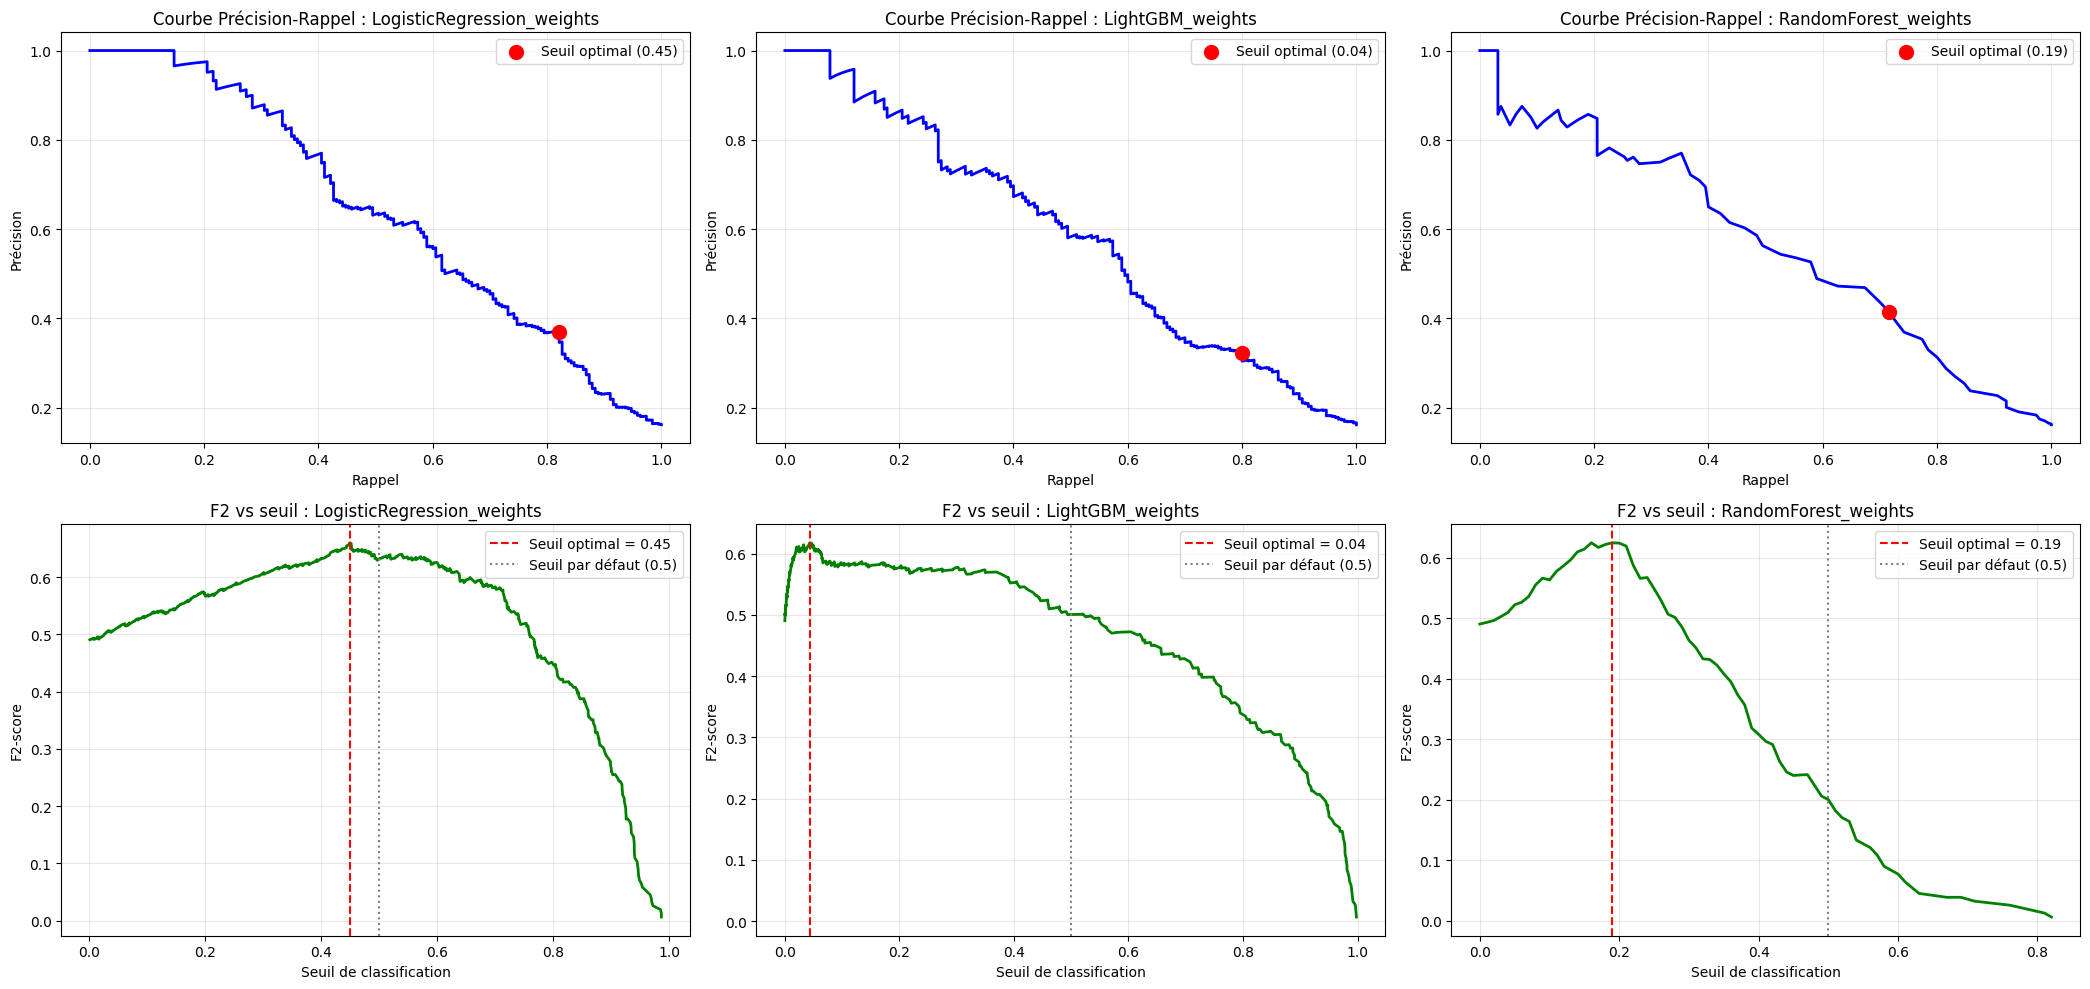

(<Figure size 2100x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'Courbe Précision-Rappel : LogisticRegression_weights'}, xlabel='Rappel', ylabel='Précision'>,
         <Axes: title={'center': 'Courbe Précision-Rappel : LightGBM_weights'}, xlabel='Rappel', ylabel='Précision'>,
         <Axes: title={'center': 'Courbe Précision-Rappel : RandomForest_weights'}, xlabel='Rappel', ylabel='Précision'>],
        [<Axes: title={'center': 'F2 vs seuil : LogisticRegression_weights'}, xlabel='Seuil de classification', ylabel='F2-score'>,
         <Axes: title={'center': 'F2 vs seuil : LightGBM_weights'}, xlabel='Seuil de classification', ylabel='F2-score'>,
         <Axes: title={'center': 'F2 vs seuil : RandomForest_weights'}, xlabel='Seuil de classification', ylabel='F2-score'>]],
       dtype=object))

In [75]:
visualiser_optimisation_seuils(resultats_seuils, beta=2)

Dans les courbes précision - rappel, on voit clairement le choix de seuil effectué pour privilégier le rappel vs la précision.

Regardons maintenant ce que cela donne au niveau de la matrice de confusion, ces données seront plus parlantes pour le métier qu'un f2-score.

### Matrice de confusion

Nous allons écrire une fonction pour tracer les matrices de confusion des 2 modèles, avec le seuil par défaut et le seuil optimisé.

In [76]:
def afficher_matrices_confusion(resultats_seuils, y_train):
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 10))
    
    for col, nom_modele in enumerate(resultats_seuils.keys()):
        res = resultats_seuils[nom_modele]
        
        y_proba_oof = res['y_proba_oof']  
        
        seuils_a_afficher = [
            ('Seuil par défaut (0.5)', 0.5, axes[0, col]),
            (f"Seuil optimal ({res['seuil_optimal']:.2f})", res['seuil_optimal'], axes[1, col]),
        ]
        
        for titre_seuil, seuil, ax in seuils_a_afficher:
            
            y_pred = (y_proba_oof >= seuil).astype(int)
            
            cm = confusion_matrix(y_train, y_pred)
            
            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=['Reste', 'Part']
            )
            disp.plot(ax=ax, cmap='Blues', colorbar=False)
            ax.set_xlabel('Predicted label')
            
            ax.set_title(f'{nom_modele}\n{titre_seuil}')
            
            tn, fp, fn, tp = cm.ravel()
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            
            ax.text(
                0.5, -0.32, 
                f"Recall = {recall:.2f} | Précision = {precision:.2f}\n"
                f"FN = {fn} (départs ratés) | FP = {fp} (fausses alertes)",
                transform=ax.transAxes,
                ha='center',
                va='top',
                fontsize=10
            )
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.6)
    plt.show()

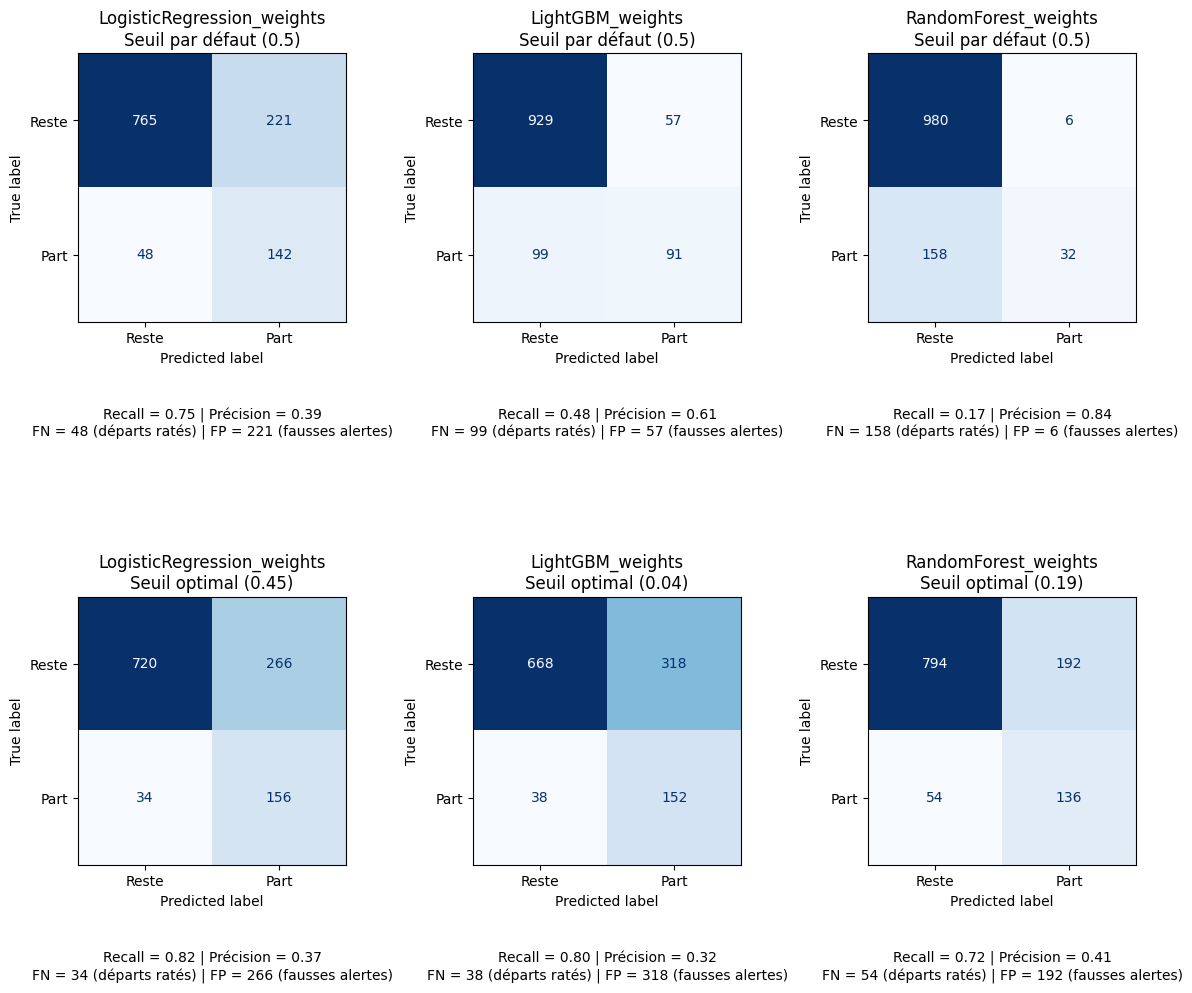

In [77]:
afficher_matrices_confusion(resultats_seuils, y_train)

Voici les enseignements ;
- Concernant la régression logistique, optimiser le seuil nous a permis de détecter 14 départs supplémentaires (les faux négatifs passent de 48 à 34), au prix de 45 fausses alertes supplémentaires (les faux positifs passent de 221 à 266).
- Concernant LightGBM, optimiser le seuil nous a permis de détecter 61 départs supplémentaires (les faux négatifs passent de 99 à 38), au prix de 261 fausses alertes supplémentaires (les faux positifs passent de 57 à 318).
- Concernant RandomForest, optimiser nous a permis de détecter 104 départs supplémentaires (les faux négatifs passent de 158 à 54), au prix de 186 fausses alertes supplémentaires (les faux positifs passent de 6 à 192).

### Feature engineering

In [78]:
extrait.columns

Index(['satisfaction_employee_environnement', 'note_evaluation_precedente',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'id_employe', 'age', 'genre', 'revenu_mensuel',
       'statut_marital', 'poste', 'nombre_experiences_precedentes',
       'annees_dans_l_entreprise', 'a_quitte_l_entreprise',
       'nombre_participation_pee', 'nb_formations_suivies',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'frequence_deplacement', 'annees_depuis_la_derniere_promotion'],
      dtype='str')

**Features binaires**

Au vu de l'EDA, certaines features semblent liées à des seuils. Ceux-ci peuvent être captés par LightGBM et RandomForest mais ne seront pas captés par la régression logistique :
- on note des taux de départ plus fort pour les personnes de moins de 33 ans
- on note des taux de départ plus fort pour les revenus < 3000€
- on note des taux de départ plus fort la première année dans l'entreprise
- on note des taux de départ plus fort chez les employés sans PEE
- on teste si les taux de départ sont plus forts spécifiquement chez les jeunes durant la première année dans l'entreprise

**Features combinées**

Certaines combinaisons nous permettent de capter des informations métiers supplémentaires :
- une feature de satisfaction globale, calculant la moyenne des notes de satisfaction
- une feature indiquant, de 0 à 1, à quel point l'employé stagne dans son poste actuel (si cela fait longtemps qu'il est dans la société, et qu'il n'a jamais eu de promotion, le score sera très proche de 1)
- une feature calculant combien de temps en moyenne la personne reste dans une entreprise donné
- une feature calculant si l'employé est mieux ou moins bien payé que la médiane des employés ayant le même poste que lui
- une feature calculant si l'employé est mieux ou moins bien payé que la médiane des employés ayant le même niveau d'éducation que lui

Ajoutons cette partie feature engineering à notre pipeline. Cela nous permet d'éviter du data leakage, qui interviendrait lors du calcul des médianes sur la totalité du jeu d'entrainement (mediane des employés ayant le même poste / niveau d'éducation), tandis que nous appliquons la cross-validation

Voici la nouvelle classe, nous n'avons besoin d'entrainer que les variables basées sur des médianes

In [79]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        pass
    
    def fit(self, X, y=None): 
        self.mediane_par_poste_ = (
            X.groupby('poste')['revenu_mensuel'].median()
        )
        self.mediane_par_education_ = (
            X.groupby('niveau_education')['revenu_mensuel'].median()
        )
        return self
    
    def transform(self, X):
        X = X.copy()
        
        X['jeune'] = (X['age'] < 33).astype(int)
        X['bas_revenu'] = (X['revenu_mensuel'] < 3000).astype(int)
        X['premiere_annee'] = (X['annees_dans_l_entreprise'] < 1).astype(int)
        X['sans_pee'] = (X['nombre_participation_pee'] == 0).astype(int)
        X['jeune_et_premiere_annee'] = (
            (X['age'] < 33) & (X['annees_dans_l_entreprise'] < 1)
        ).astype(int)
        
        X['satisfaction_globale'] = (
            X['satisfaction_employee_environnement']
            + X['satisfaction_employee_nature_travail']
            + X['satisfaction_employee_equipe']
            + X['satisfaction_employee_equilibre_pro_perso']
        ) / 4
        
        X['ratio_stagnation'] = (
            X['annees_depuis_la_derniere_promotion']
            / (X['annees_dans_l_entreprise'] + 0.1)
        )
        
        X['ratio_salaire_mediane_poste'] = (
            X['revenu_mensuel'] / X['poste'].map(self.mediane_par_poste_)
        )
        X['ratio_salaire_mediane_education'] = (
            X['revenu_mensuel'] / X['niveau_education'].map(self.mediane_par_education_)
        )
        
        return X

Adaptons le preprocessor pour prendre en compte ces nouvelles features numériques

In [80]:
nouvelles_features_num = [
    'jeune', 'bas_revenu', 'premiere_annee', 'sans_pee',
    'jeune_et_premiere_annee', 'satisfaction_globale',
    'ratio_stagnation', 'ratio_salaire_mediane_poste',
    'ratio_salaire_mediane_education'
]
cols_numeriques_etendues = cols_numeriques + nouvelles_features_num

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), 
     col_qualitatives_nominales),
    ('num', Pipeline([('scaler', StandardScaler())]), cols_numeriques_etendues),
])

Créons maintenant les nouveaux pipelines, en prenant en compte le feature engineering et le preprocessor mis à jour

In [81]:
pipelines_with_fe = {
    'LogisticRegression_FE': Pipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ))
    ]),
    'LightGBM_FE': Pipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(
            class_weight='balanced', random_state=42, verbosity=-1
        ))
    ]),
    'RandomForest_FE': Pipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            class_weight='balanced', random_state=42
        ))
    ])
}

Testons maintenant nos modèles avec les nouvelles features et la cross validation

In [82]:
scores_cv_fe = []
for name, pipeline in pipelines_with_fe.items():
    scores_cv_fe.append(evaluate_model_cv(name, pipeline, X_train, y_train))
scores_cv__fe_df = pd.DataFrame(scores_cv_fe).set_index('modele').round(3)
scores_cv__fe_df

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

,recall_train,recall_test,recall_test_std,precision_train,precision_test,precision_test_std,f2_train,f2_test,f2_test_std
modele,,,,,,,,,
LogisticRegression_FE,0.816,0.758,0.031,0.441,0.418,0.044,0.697,0.650,0.021
LightGBM_FE,1.000,0.437,0.054,1.000,0.621,0.090,1.000,0.462,0.051
RandomForest_FE,1.000,0.147,0.084,1.000,0.847,0.136,1.000,0.174,0.094


On compare ici le feature engineering avec la version "class weight" de nos modèles (avant recherche de seuil optimal) :
- La régression logistique s'améliore légèrement avec un f2-score qui passe de 0.63 à 0.65. Le modèle reste stable avec σ=0.02.
- LightGBM voit sa performance baisser légèrement, passant de 0.5 à 0.46. Le modèle se stabilise avec σ=0.05.
- RandomForest voit sa performance stagner, passant de 0.18 à 0.17. Le modèle reste peu stable avec σ=0.1

==> le feature engineering a eu très peu d'impact sur la performance du modèle avec les seuils par défaut. Regardons maintenant la performance avec les seuils optimisés

In [83]:
resultats_fe_seuils = {}
for nom_modele, pipeline in pipelines_with_fe.items():
    print(f"\n{nom_modele}:")
    resultats_fe_seuils[nom_modele] = optimiser_seuil_decision(pipeline, X_train, y_train, beta=2)


LogisticRegression_FE:
  Seuil optimal           : 0.480
  → F2 = 0.658
  → Précision = 0.405, Recall = 0.779

LightGBM_FE:


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

  Seuil optimal           : 0.049
  → F2 = 0.628
  → Précision = 0.353, Recall = 0.779

RandomForest_FE:
  Seuil optimal           : 0.140
  → F2 = 0.608
  → Précision = 0.311, Recall = 0.800


Vs sans feature engineering, avec seuil optimisé ;
- La performance de la régression logistique reste stable, avec un F2 à 0.66
- La performance de LightGBM s'améliore un peu avec un F2 qui passe de 0.61 à 0.63
- La performance de RandomForest se dégrade légèrement avec un F2 qui passe de 0.62 à 0.6
- Les seuils de LightGBM et RandomForest avec feature engineering sont encore très bas ; respectivement 0.05 et 0.14

### SelectKBest

Sur ce projet, nous avons beaucoup de features (notamment numériques). Nous allons regarder si la suppression de features pourrait permettre d'améliorer la performance de nos modèles, en utilisant SelectKBest.

SelectKBest juge les features avant d'entrainer des modèles, par simples tests statistique. Comme nous avons très majoritairement des features numériques, nous allons utiliser pour fonction de score de SelectKBest 'f_classif' (ANOVA F-test).

Nous allons créer une fonction prenant en entrée un modèle, et renvoyant ses scores en cross-validation, avec et sans SelectKBest. Pour l'ordre de la pipeline, on créé d'abord les nouvelles features (feature engineering), puis on applique l'encoding & le scaling (preprocessor) et enfin lorsque les features sont "prêtes", on ajoute SelectKBest

In [84]:
def comparer_select_au_seuil_optimise(nom, modele, X_train, y_train, k=20):
    
    pipe_sans = ImbPipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('model', modele),
    ])
    pipe_avec = ImbPipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('select', SelectKBest(score_func=f_classif, k=k)),
        ('model', modele),
    ])

    r_sans = optimiser_seuil_decision(pipe_sans, X_train, y_train, beta=2, verbose=False)
    r_avec = optimiser_seuil_decision(pipe_avec, X_train, y_train, beta=2, verbose=False)

    return [
        {'config': f"{nom} (sans select)", 'f2': r_sans['f_beta_optimal'],
         'seuil': r_sans['seuil_optimal'], 'recall': r_sans['recall_optimal'],
         'precision': r_sans['precision_optimal']},
        {'config': f"{nom} (k={k})", 'f2': r_avec['f_beta_optimal'],
         'seuil': r_avec['seuil_optimal'], 'recall': r_avec['recall_optimal'],
         'precision': r_avec['precision_optimal']},
    ]

Combien y-a-t-il de features après feature engineering et encoding ?

In [85]:
pipe_prepa = ImbPipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
])
X_prepare = pipe_prepa.fit_transform(X_train, y_train)

nb_features = X_prepare.shape[1]
print(f"Nombre de features au moment de SelectKBest : {nb_features}")

Nombre de features au moment de SelectKBest : 42


Testons maintenant SelectKBest sur les modèles, on va tester k=20.

In [86]:
modeles = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest':       RandomForestClassifier(class_weight='balanced', random_state=42),
    'LightGBM':           LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1),
}

lignes = []
for nom, modele in modeles.items():
    lignes.extend(comparer_select_au_seuil_optimise(nom, modele, X_train, y_train, k=20))

pd.DataFrame(lignes).set_index('config').round(3)

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

,f2,seuil,recall,precision
config,,,,
LogisticRegression (sans select),0.658,0.480,0.779,0.405
LogisticRegression (k=20),0.656,0.484,0.784,0.396
RandomForest (sans select),0.608,0.140,0.800,0.311
RandomForest (k=20),0.582,0.140,0.737,0.317
LightGBM (sans select),0.628,0.049,0.779,0.353
LightGBM (k=20),0.588,0.027,0.811,0.281


Quelque soit le modèle, le f2-score baisse lorsque l'on retire des features. Partons maintenant de notre meilleur modèle non-linéaire (LightGBM), et testons plus en détail la variation du f-score selon k.

In [87]:
ks = list(range(5, nb_features + 1, 5)) + [nb_features]  # 5, 10, 15... jusqu'au total
ks = sorted(set(ks))

courbe = []
for k in ks:
    pipe = ImbPipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('select', SelectKBest(score_func=f_classif, k=k)),
        ('model', LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1)),
    ])
    r = optimiser_seuil_decision(pipe, X_train, y_train, beta=2, verbose=False)
    courbe.append({'k': k, 'f2': r['f_beta_optimal']})

courbe_df = pd.DataFrame(courbe).set_index('k')
print(courbe_df.round(3))

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

       f2
k        
5   0.504
10  0.546
15  0.576
20  0.588
25  0.600
30  0.590
35  0.626
40  0.620
42  0.628


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

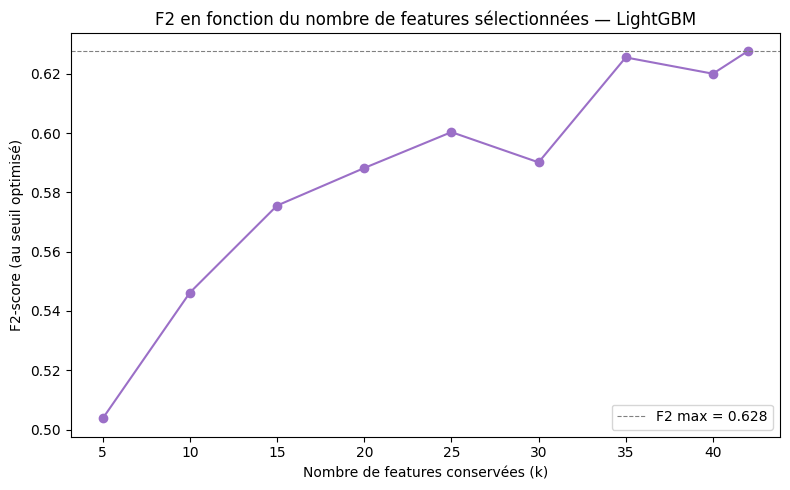

In [88]:
fig, ax = plt.subplots(figsize=(8, 5))

# La courbe elle-même : F2 en fonction de k
ax.plot(courbe_df.index, courbe_df['f2'], marker='o', color='#9B6FC7')

# Repère du maximum (k=42, ton jeu complet)
f2_max = courbe_df['f2'].max()
ax.axhline(f2_max, color='grey', linestyle='--', linewidth=0.8,
           label=f'F2 max = {f2_max:.3f}')

ax.set_xlabel("Nombre de features conservées (k)")
ax.set_ylabel("F2-score (au seuil optimisé)")
ax.set_title("F2 en fonction du nombre de features sélectionnées — LightGBM")
ax.legend()
plt.tight_layout()
plt.show()

On observe que le meilleur f2-score est obtenu lorsque l'on a toutes les features (42)
à 35 features, on obtient quasi le même score mais ;
- ce score est dans le bruit (pour le f2-score, σ=0.05)
- on ne connait pas les 7 features qui seraient retirées (SelectKBest est dans le pipeline, à chaque pli de CV les features sont potentiellement différentes)
- passer de 42 à 35 features n'améliore pas l'interpretabilité de manière assez significative (ni le temps de calcul)

En conclusion, j'ai décidé de garder le jeu de données complet.

### Déséquilibre de classe ; SMOTE

Nous allons maintenant tester SMOTE comme alternative à `class_weight='balanced'` pour valider que la solution retenue est bien la meilleure. SMOTE crée des exemples synthétiques de la classe minoritaire en interpolant entre les voisins existants, alors que `class_weight` se contente de pondérer la fonction de coût.

Deux points d'attention :
- J'utilise `imblearn.pipeline.Pipeline` (et non celle de sklearn) pour que SMOTE ne s'applique qu'aux folds d'entraînement de la CV, jamais aux folds de validation (pas de fuite).
- Je retire `class_weight='balanced'` du modèle : SMOTE rééquilibre déjà les classes en amont, doubler la correction n'a pas de sens.

In [89]:
pipelines_smote = {
    'LogisticRegression_SMOTE': ImbPipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'LightGBM_SMOTE': ImbPipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LGBMClassifier(random_state=42, verbosity=-1))
    ]),
    'RandomForest_SMOTE': ImbPipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ])
}

In [90]:
scores_cv_smote = []
for name, pipeline in pipelines_smote.items():
    scores_cv_smote.append(evaluate_model_cv(name, pipeline, X_train, y_train))
scores_cv_smote_df = pd.DataFrame(scores_cv_smote).set_index('modele').round(3)
scores_cv_smote_df

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

,recall_train,recall_test,recall_test_std,precision_train,precision_test,precision_test_std,f2_train,f2_test,f2_test_std
modele,,,,,,,,,
LogisticRegression_SMOTE,0.799,0.737,0.047,0.453,0.420,0.038,0.693,0.638,0.026
LightGBM_SMOTE,1.000,0.395,0.088,1.000,0.686,0.121,1.000,0.429,0.087
RandomForest_SMOTE,1.000,0.305,0.046,1.000,0.739,0.147,1.000,0.344,0.046


Sans recherche du seuil optimisé, vs "class weight" ;
- Régression logistique : SMOTE a une performance légèrement inférieure, 0.64 vs 0.65
- LightGBM : SMOTE a une performance légèrement inférieure encore, 0.43 vs 0.46
- RandomForest : SMOTE a une bien meilleure performance, 0.34 vs 0.17

Regardons maintenant ce qui se passe lorsque l'on optimise le seuil

In [91]:
resultats_smote_seuils = {}
for nom_modele, pipeline in pipelines_smote.items():
    print(f"\n{nom_modele}:")
    resultats_smote_seuils[nom_modele] = optimiser_seuil_decision(pipeline, X_train, y_train, beta=2)

resultats_smote_seuils_df = pd.DataFrame({
    nom: {
        'seuil_optimal': res['seuil_optimal'],
        'f2_optimal': res['f_beta_optimal'],
        'precision_optimal': res['precision_optimal'],
        'recall_optimal': res['recall_optimal']
    }
    for nom, res in resultats_smote_seuils.items()
}).T.round(3)
resultats_smote_seuils_df


LogisticRegression_SMOTE:
  Seuil optimal           : 0.605
  → F2 = 0.658
  → Précision = 0.496, Recall = 0.716

LightGBM_SMOTE:


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

  Seuil optimal           : 0.035
  → F2 = 0.612
  → Précision = 0.350, Recall = 0.753

RandomForest_SMOTE:
  Seuil optimal           : 0.220
  → F2 = 0.644
  → Précision = 0.350, Recall = 0.816


,seuil_optimal,f2_optimal,precision_optimal,recall_optimal
LogisticRegression_SMOTE,0.605,0.658,0.496,0.716
LightGBM_SMOTE,0.035,0.612,0.350,0.753
RandomForest_SMOTE,0.220,0.644,0.350,0.816


Vs class weight, avec seuil optimisé ;
- La performance de la régression logistique est similaire, avec un F2 à 0.66
- La performance de LightGBM est légèrement moins bonne, avec un F2 à 0.61 (vs 0.63)
- La performance de RandomForest est légèrement meilleure, avc un F2 à 0.64 (vs 0.6)

J'ai validé que ma gestion du déséquilibre est robuste — deux méthodes radicalement différentes donnent les mêmes performances finales. Pour la suite, je retiens `class_weight` pour sa simplicité (pas de génération de données artificielles).

### Test des modèles sur le jeu de test

L'étape 4 demande explicitement de tester un modèle non-linéaire sur le jeu de test, regardons LightGBM et précisemment la version avec class weight, seuil optimisé et feature engineering - qui a pour f2-score 0.63

In [92]:
pipeline_etape4 = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        verbosity=-1
    ))
])

pipeline_etape4.fit(X_train, y_train)

y_proba_test = pipeline_etape4.predict_proba(X_test)[:, 1]

seuil_optimal = resultats_fe_seuils['LightGBM_FE']['seuil_optimal']
y_pred_test = (y_proba_test >= seuil_optimal).astype(int)

recall_final = recall_score(y_test, y_pred_test)
precision_final = precision_score(y_test, y_pred_test)
f2_final = fbeta_score(y_test, y_pred_test, beta=2)
f1_final = f1_score(y_test, y_pred_test)

f2_cv = resultats_fe_seuils['LightGBM_FE']['f_beta_optimal']
recall_cv = resultats_fe_seuils['LightGBM_FE']['recall_optimal']
precision_cv = resultats_fe_seuils['LightGBM_FE']['precision_optimal']

print(f"=== Évaluation finale — LightGBM + FE sur X_test ({len(y_test)} employés) ===\n")
print(f"Seuil appliqué : {seuil_optimal:.3f} (déterminé en CV sur X_train)\n")

print(f"{'Métrique':<12} {'CV (attendu)':<15} {'X_test (réel)':<15} {'Écart':<10}")
print(f"{'-'*52}")
print(f"{'F2-score':<12} {f2_cv:<15.3f} {f2_final:<15.3f} {f2_final-f2_cv:+.3f}")
print(f"{'Recall':<12} {recall_cv:<15.3f} {recall_final:<15.3f} {recall_final-recall_cv:+.3f}")
print(f"{'Précision':<12} {precision_cv:<15.3f} {precision_final:<15.3f} {precision_final-precision_cv:+.3f}")
print(f"\nF1-score sur X_test : {f1_final:.3f} (pour info)")

=== Évaluation finale — LightGBM + FE sur X_test (294 employés) ===

Seuil appliqué : 0.049 (déterminé en CV sur X_train)

Métrique     CV (attendu)    X_test (réel)   Écart     
----------------------------------------------------
F2-score     0.628           0.587           -0.040
Recall       0.779           0.745           -0.034
Précision    0.353           0.318           -0.035

F1-score sur X_test : 0.446 (pour info)


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


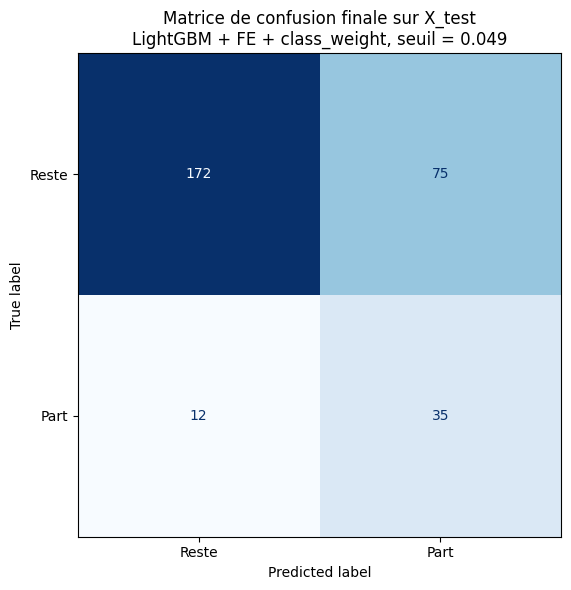

In [93]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['Reste', 'Part'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)
ax.set_title(
    f"Matrice de confusion finale sur X_test\n"
    f"LightGBM + FE + class_weight, seuil = {seuil_optimal:.3f}"
)
plt.tight_layout()
plt.show()

**Lecture métier de la matrice de confusion**

Sur les 294 employés de X_test, dont 47 partent réellement :
- **35 départs détectés** (vrais positifs) — soit 74% des départs anticipés
- **12 départs ratés** (faux négatifs) — coût RH lourd : turnover non anticipé
- **75 fausses alertes** (faux positifs) — coût RH limité : pour actions à déterminer (entretien préventif, prime de fidélisation, ...)
- **172 employés correctement identifiés comme restants** (vrais négatifs)

Ce compromis est cohérent avec le choix de la métrique de score (F2-score, β=2 qui privilégie le recall) : les entretiens préventifs inutiles coutent moins cher que les départs anticipables ratés.

**Limites**

- Le modèle rate environ 1 départ sur 4 (recall = 74%) — il ne s'agit pas d'un détecteur parfait, mais d'un outil d'aide à la décision.
- Le taux de fausses alertes (30% des employés restants) est significatif, à prendre en compte pour les RH dans les "pour actions".

# 5. Optimisation et interprétation du modèle

Passons à l'optimisation du modèle LightGBM. Pour tester différentes combinaisons d'hyperparamètres, nous allons utiliser Optuna, ce qui permettra de converger plus rapidement qu'un simple GridSearchCV.

### Import des modules

In [94]:
import optuna
from optuna.samplers import TPESampler
import optuna.visualization as vis
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score
import shap

### Fine-tuning avec Optuna

Définissons la fonction objectif d'Optuna, on repart sur notre stratégie précédente ;
- f2-score
- Stratification avec StratifiedKFold
- Avec Class weight
- Avec feature engineering

Et le but d'Optuna sera ici d'optimiser l'average precision (l'aire de la courbe précision rappel), nous pourrons ensuite choisir le seuil adéquat (au lieu de partir directement sur une optimisation du f2-score, où le seuil aurait été fixé arbitrairement par Optuna à 0.5).

In [95]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def objective_lightgbm(trial):
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': 1
    }
    
    pipeline_trial = Pipeline([
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(**params))
    ])
    
    scores = cross_validate(
        pipeline_trial, X_train, y_train,
        cv=cv_strat,
        scoring={'ap': 'average_precision'},
        n_jobs=-1
    )
    
    return scores['test_ap'].mean()

In [96]:
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='lightgbm_attrition_p4'
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study.optimize(
    objective_lightgbm,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-06-02 09:30:32,144] A new study created in memory with name: lightgbm_attrition_p4


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

Nous allons maintenant comparer l'average precision de l'étape 4 (sans fine-tuning) avec l'average precision de l'étape 5 (avec fine-tuning via Optuna).

In [97]:
ap_reference_etape4 = cross_val_score(
    pipelines_with_fe['LightGBM_FE'], X_train, y_train,
    cv=cv_strat, scoring='average_precision', n_jobs=-1
).mean()

ap_optuna = study.best_value

print("=== Niveau 1 : ce qu'Optuna optimise (average precision, sans seuil) ===\n")
print(f"AP LightGBM_FE étape 4 (CV)  : {ap_reference_etape4:.3f}")
print(f"AP LightGBM optimisé (CV)    : {ap_optuna:.3f}")
print(f"Gain d'AP                    : {ap_optuna - ap_reference_etape4:+.3f}")

print("\n=== Meilleurs hyperparamètres trouvés ===")
for k, v in study.best_params.items():
    if isinstance(v, float):
        print(f"  {k:25s} : {v:.4f}")
    else:
        print(f"  {k:25s} : {v}")

=== Niveau 1 : ce qu'Optuna optimise (average precision, sans seuil) ===

AP LightGBM_FE étape 4 (CV)  : 0.595
AP LightGBM optimisé (CV)    : 0.645
Gain d'AP                    : +0.049

=== Meilleurs hyperparamètres trouvés ===
  n_estimators              : 165
  learning_rate             : 0.1103
  num_leaves                : 85
  max_depth                 : 11
  min_child_samples         : 65
  reg_alpha                 : 0.0000
  reg_lambda                : 2.2501


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

On obtient un gain significatif, l'average precision passant de 0.6 à 0.65.
Sur Optuna spécifiquement, regardons la vitesse de convergence ainsi que l'importance des différents hyperparamètres

In [98]:
fig_history = vis.plot_optimization_history(study)
fig_history.update_layout(
    title="Historique d'optimisation Optuna",
    xaxis_title="Essai n°",
    yaxis_title="F2-score"
)
fig_history.show()

fig_importance = vis.plot_param_importances(study)
fig_importance.update_layout(
    title="Importance relative des hyperparamètres"
)
fig_importance.show()

La convergence d'Optuna est rapide, au 7ème essai il avait déjà atteint une average precision de 0.64, proche du max.
Les 2 hyper-paramètres les plus important sont `min_child_samples` et `learning_rate`.
- `min_child_sample` définit le nombre minimal d'échantillons requis dans une feuille pour que l'arbre ait le droit de créer cette séparation. Il permet de contrôler l'overfitting
- `learning_rate`contrôle à quelle vitesse le modèle apprend

Nous allons maintenant partir de ce modèle avec hyperparamètres optimisés, et regarder si l'on peut encore améliorer la performance en optimisant le seuil de décision.

Nous comparerons ces résultats aux résultats de l'étape 4 après optimisation du seuil afin de vérifier si l'optimisation des hyperparamètres améliore les résultats lorsque l'on part du modèle avec seuil optimisé.

In [99]:
meilleurs_params = study.best_params.copy()
meilleurs_params['class_weight'] = 'balanced'
meilleurs_params['random_state'] = 42
meilleurs_params['verbosity'] = -1

pipeline_optimise = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(**meilleurs_params))
])

resultats_optimise = optimiser_seuil_decision(
    pipeline_optimise, X_train, y_train, beta=2
)

print(f"\n=== Comparaison finale (CV) ===")
print(f"{'Configuration':<40} {'F2':<8} {'Seuil':<8} {'Recall':<8} {'Précision':<8}")
print("-" * 80)
print(f"{'Étape 4 - LightGBM_FE défaut':<40} "
      f"{resultats_fe_seuils['LightGBM_FE']['f_beta_optimal']:<8.3f} "
      f"{resultats_fe_seuils['LightGBM_FE']['seuil_optimal']:<8.3f} "
      f"{resultats_fe_seuils['LightGBM_FE']['recall_optimal']:<8.3f} "
      f"{resultats_fe_seuils['LightGBM_FE']['precision_optimal']:<8.3f}")
print(f"{'Étape 5 - LightGBM tuné Optuna':<40} "
      f"{resultats_optimise['f_beta_optimal']:<8.3f} "
      f"{resultats_optimise['seuil_optimal']:<8.3f} "
      f"{resultats_optimise['recall_optimal']:<8.3f} "
      f"{resultats_optimise['precision_optimal']:<8.3f}")

  Seuil optimal           : 0.371
  → F2 = 0.644
  → Précision = 0.487, Recall = 0.700

=== Comparaison finale (CV) ===
Configuration                            F2       Seuil    Recall   Précision
--------------------------------------------------------------------------------
Étape 4 - LightGBM_FE défaut             0.628    0.049    0.779    0.353   
Étape 5 - LightGBM tuné Optuna           0.644    0.371    0.700    0.487   


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

L'optimisation du seuil a apporté une très légère amélioration du f2-score, avec un passage de 0.641 à 0.644.

Si l'on compare maintenant aux résultats de l'étape 4 (sans optimisation Optuna), on observe également :
- un seuil plus "standard" à 0.371 (vs 0.049 sans optimisation Optuna), beaucoup plus simple à expliquer au métier
- un compromis précision - recall différent avec une meilleure précision (0.49 au lieu de 0.35) au prix d'un recall moins bon (0.7 au lieu de 0.78) 

Toujours par rapport à l'étape 4 (sans fine-tuning), visualisons la courbe précision-rappel ainsi que l'optimisation du seuil.

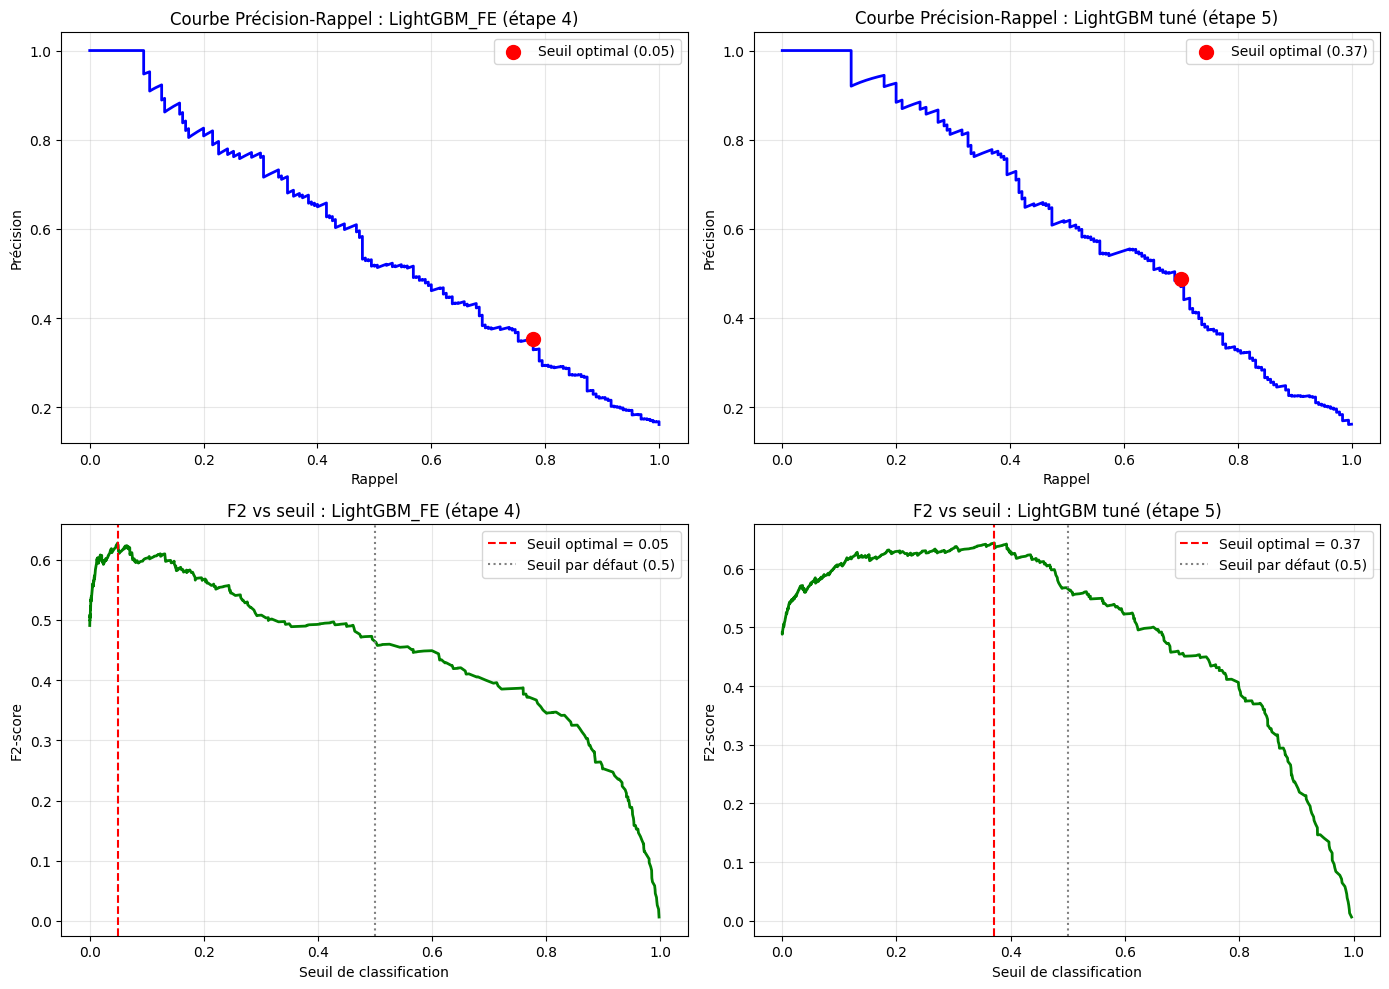

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Courbe Précision-Rappel : LightGBM_FE (étape 4)'}, xlabel='Rappel', ylabel='Précision'>,
         <Axes: title={'center': 'Courbe Précision-Rappel : LightGBM tuné (étape 5)'}, xlabel='Rappel', ylabel='Précision'>],
        [<Axes: title={'center': 'F2 vs seuil : LightGBM_FE (étape 4)'}, xlabel='Seuil de classification', ylabel='F2-score'>,
         <Axes: title={'center': 'F2 vs seuil : LightGBM tuné (étape 5)'}, xlabel='Seuil de classification', ylabel='F2-score'>]],
       dtype=object))

In [100]:
resultats_comparaison = {
    'LightGBM_FE (étape 4)': resultats_fe_seuils['LightGBM_FE'],
    'LightGBM tuné (étape 5)': resultats_optimise
}

visualiser_optimisation_seuils(resultats_comparaison, beta=2)

Avec optimisation des hyperparamètres, on observe :
- une courbe précision - rappel clairement "meilleure" ; pour un même rappel, la précision est meilleure
- une plage de "seuils optimaux" plus grande ; à l'étape 4, seuls les seuils autour de 0.05 étaient optimaux. Après fine-tuning, tous les seuils entre ~0.11 et ~0.45 permettent d'avoir un f2-score > 0.6

Passons maintenant à l'interprétation du modèle, en démarrant par la feature importance native de LightGBM vu que c'est un modèle à base d'arbres

### Interprétation : feature importance

la feature importance native d'un modèle d'arbre répond à la question : "à quel point l'arbre s'est-il appuyé sur cette feature pour découper la population ?"

NB : `optimiser_seuil_decision`a évalué la pipeline en cross validation, mais l'objet `pipeline_optimise` lui-même n'a jamais été entrainé. On l'entraine explicitement sur tout `X_train` avant de l'inspecter

In [101]:
pipeline_optimise.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

Récupérons le nom des features après l'étape de preprocessing, et affichons les top feature importance triés

In [102]:
modele = pipeline_optimise.named_steps['model']

noms_features = pipeline_optimise.named_steps['preprocessor'].get_feature_names_out()

importance_native = pd.Series(
    modele.feature_importances_,
    index=noms_features
).sort_values(ascending=False)

importance_native.head(15)

num__ratio_salaire_mediane_poste             231
num__ratio_salaire_mediane_education         211
num__age                                     189
num__distance_domicile_travail               156
num__revenu_mensuel                          143
num__ratio_stagnation                        125
num__annees_dans_l_entreprise                124
num__satisfaction_globale                    102
num__nombre_experiences_precedentes           82
onehot__heure_supplementaires_Oui             73
num__nombre_participation_pee                 64
num__frequence_deplacement                    61
num__satisfaction_employee_environnement      57
num__satisfaction_employee_nature_travail     55
num__note_evaluation_precedente               50
dtype: int32

Mais `.feature_importances` mesure par défaut le split (le nombre de fois qu'une variable coupe les données)
Il y a une autre manière de mesurer l'importance, que nous allons appliquer ici, `feature_importance(importance_type='gain')`. Cette commande mesure l'amélioration de la précision apportée par les variables.

In [103]:
importance_gain = pd.Series(
    modele.booster_.feature_importance(importance_type='gain'),
    index=noms_features
).sort_values(ascending=False)
importance_gain.head(15)

num__age                                          669.458576
num__ratio_salaire_mediane_education              609.538124
num__ratio_salaire_mediane_poste                  594.761270
num__annees_dans_l_entreprise                     590.917114
onehot__heure_supplementaires_Oui                 527.230797
num__satisfaction_globale                         466.921163
num__revenu_mensuel                               377.531473
num__nombre_participation_pee                     344.655850
num__distance_domicile_travail                    314.832437
num__ratio_stagnation                             264.419482
num__nombre_experiences_precedentes               254.399176
num__frequence_deplacement                        207.683616
onehot__poste_Cadre Commercial                    183.628580
num__satisfaction_employee_environnement          149.817220
num__satisfaction_employee_equilibre_pro_perso    137.785675
dtype: float64

En regardant le gain (ce qui est interprétable côté métier), on observe une distribution des features importance différente. Visualisons cela avec un graphique

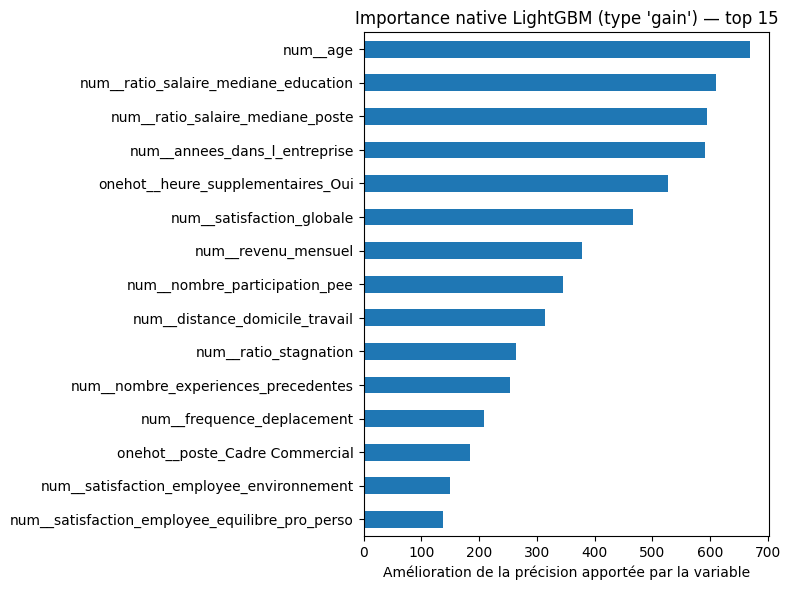

In [104]:
fig, ax = plt.subplots(figsize=(8, 6))
importance_gain.head(15).sort_values().plot.barh(ax=ax)
ax.set_title("Importance native LightGBM (type 'gain') — top 15")
ax.set_xlabel("Amélioration de la précision apportée par la variable")
plt.tight_layout()
plt.show()

Définissons maintenant une fonction pour récupérer les features les plus importantes, de manière à ce que la somme cumulée de leur importance soit supérieure à un seuil (ici 80%).

In [105]:
def get_features_most_importance(importances, feature_names, threshold=0.8):
    importances = np.asarray(importances, dtype=float)

    # Les importances négatives (permutation) = au mieux du bruit → on les ramène à 0
    # pour que le "cumul à X%" porte sur des contributions positives uniquement.
    importances = np.clip(importances, 0, None)

    sorted_indices = np.argsort(importances)[::-1]
    sorted_importances = importances[sorted_indices]
    sorted_features_names = [feature_names[i] for i in sorted_indices]

    total = sorted_importances.sum()
    cumulated_importance = 0.0
    important_features = []

    for importance, feature_name in zip(sorted_importances, sorted_features_names):
        cumulated_importance += importance
        important_features.append(feature_name)
        if cumulated_importance >= threshold * total:
            print(f"Seuil de {threshold*100:.0f}% atteint avec "
                  f"{len(important_features)} features : \n "
                  f"{',\n '.join(important_features)}\n"
                  )
            break

    return important_features


In [106]:
important_features_feat = get_features_most_importance(
    importance_gain.values, importance_gain.index.tolist(), threshold=0.8
)

Seuil de 80% atteint avec 13 features : 
 num__age,
 num__ratio_salaire_mediane_education,
 num__ratio_salaire_mediane_poste,
 num__annees_dans_l_entreprise,
 onehot__heure_supplementaires_Oui,
 num__satisfaction_globale,
 num__revenu_mensuel,
 num__nombre_participation_pee,
 num__distance_domicile_travail,
 num__ratio_stagnation,
 num__nombre_experiences_precedentes,
 num__frequence_deplacement,
 onehot__poste_Cadre Commercial



### Interprétation : Permutation importance

La permutation importance applique une méthode différente ; "si je supprime telle feature, à quelle point la performance va-t-elle chûter ?". On l'applique à notre jeu de test.

In [107]:
perm = permutation_importance(
    pipeline_optimise,
    X_test, y_test,
    scoring='average_precision',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_perm = pd.DataFrame({
    'importance': perm.importances_mean,
    'std': perm.importances_std
}, index=X_train.columns).sort_values('importance', ascending=False)

importance_perm.head(15)

/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/ut

,importance,std
heure_supplementaires,0.181966,0.022186
frequence_deplacement,0.047962,0.018400
nombre_participation_pee,0.035974,0.021351
satisfaction_employee_nature_travail,0.025383,0.012642
revenu_mensuel,0.022127,0.026265
age,0.021532,0.032664
domaine_etude,0.017467,0.007669
distance_domicile_travail,0.010592,0.020418
satisfaction_employee_equilibre_pro_perso,0.009620,0.008268
satisfaction_employee_environnement,0.009521,0.020829


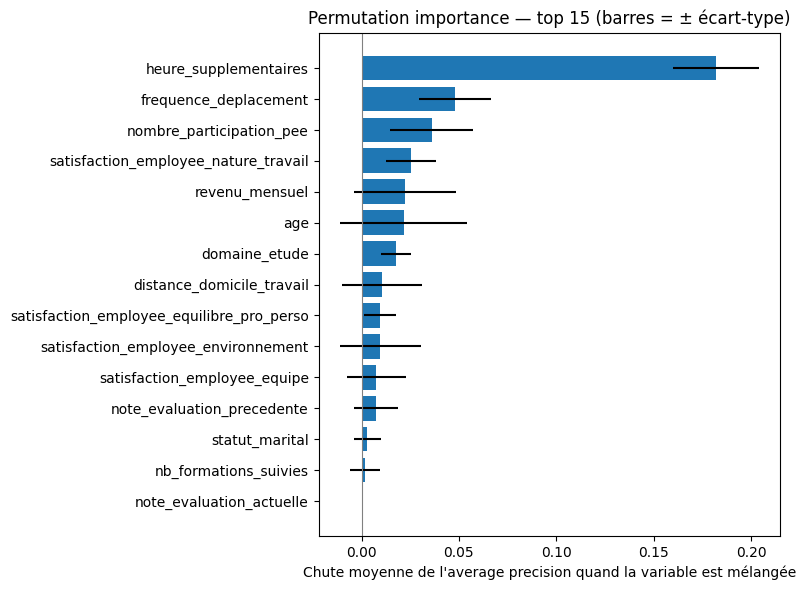

In [108]:
top = importance_perm.head(15).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top['importance'], xerr=top['std'])
ax.axvline(0, color='grey', lw=0.8)
ax.set_title("Permutation importance — top 15 (barres = ± écart-type)")
ax.set_xlabel("Chute moyenne de l'average precision quand la variable est mélangée")
plt.tight_layout()
plt.show()

On note que les écarts-types sont relativement faibles, ils ne mettent pas en cause la liste des top features.

In [109]:
important_features_perm = get_features_most_importance(
    importance_perm['importance'].values, importance_perm.index.tolist(), threshold=0.8
)

Seuil de 80% atteint avec 6 features : 
 heure_supplementaires,
 frequence_deplacement,
 nombre_participation_pee,
 satisfaction_employee_nature_travail,
 revenu_mensuel,
 age



### Interprétation : Beeswarm Plot

Visualisons maintenant le Beeswarm Plot du package SHAP. Il se base donc sur les valeurs de Shapley, calculs de feature importance local.

Forme des valeurs SHAP : (1176, 42)


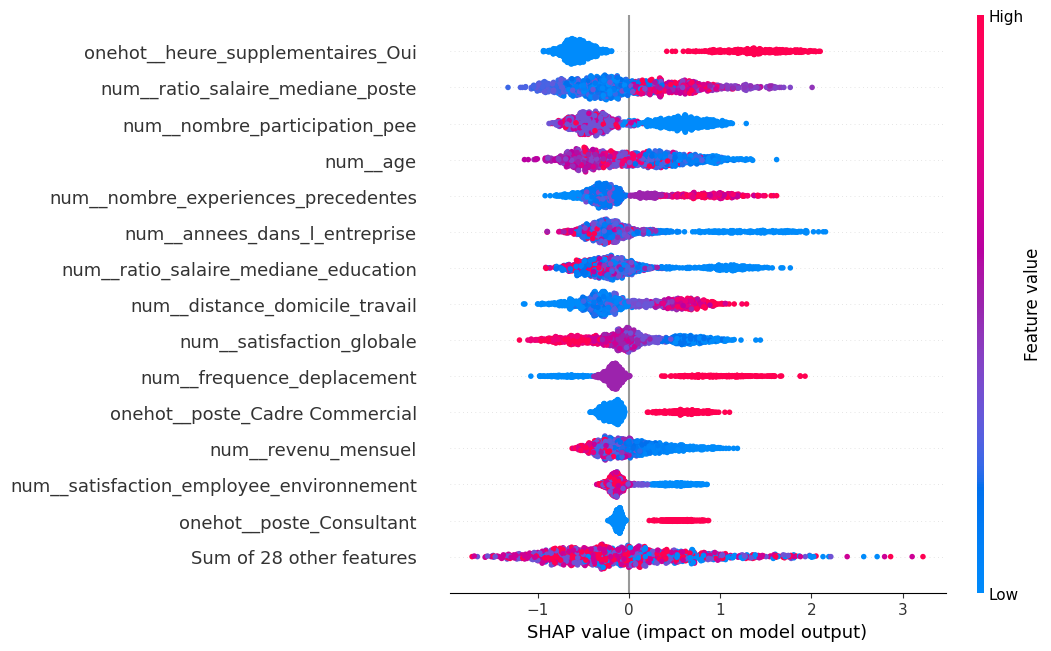

In [110]:
modele = pipeline_optimise.named_steps['model']

X_train_transforme = pipeline_optimise[:-1].transform(X_train)

noms_features = pipeline_optimise.named_steps['preprocessor'].get_feature_names_out()
X_train_transforme = pd.DataFrame(
    X_train_transforme, columns=noms_features, index=X_train.index
)

explainer = shap.TreeExplainer(modele)

explanation = explainer(X_train_transforme)
print("Forme des valeurs SHAP :", explanation.shape)

shap.plots.beeswarm(explanation, max_display=15)

Comme nous allons le voir ci-dessous, cette méthode vient confirmer les apprentissages des 2 autres méthodes.

### Interprétation des 3 méthodes

Les 3 méthodes racontent la même histoire

**Ce qui converge, peu importe la méthode**
- `heures_supplementaires`: n°5 en native, n°1 en permutation, n°1 en SHAP.
- `nombre_participation_pee`: n°8 en native, n°3 en permutation, n°3 en SHAP.

**Le désaccord apparent, qui n'en est pas un**
`revenu_mensuel` est n°5 en permutation, mais seulement n°7 en native et n°12 en SHAP. Ce désaccord apparent vient de mon feature engineering, qui crée 3 features supplémentaires ; `ratio_salaire_mediane_poste`, `ratio_salaire_mediane_education` et `bas_revenu` - le signal du salaire se retrouve donc réparti entre elles, et les deux ratios captent même l'essentiel (`ratio_salaire_mediane_poste` n°3 native / n°2 SHAP, `ratio_salaire_mediane_education` n°2 native / n°7 SHAP), ce qui laisse la valeur brute plus bas. La permutation, elle, permute la valeur brute : elle calcule l'effet total du salaire, qui remonte alors à n°5.

**Le cas miroir qui n'en est pas un**
La satisfaction raconte exactement l'histoire inverse. Côté native (n°6) et SHAP (n°9), l'agrégat `satisfaction_globale` ressort. Côté permutation, on voit à la place les quatre composantes d'origine éparpillées (`nature_travail` n°4, `equilibre_pro_perso` n°9, `environnement` n°10, `equipe` n°11).

SHAP et son Beeswarm Plot ne permettent pas simplement de voir les variables importantes, mais aussi dans quel sens. Ainsi, dans le sens d'un départ plus probable, on retrouve ;
- faire des heures sup
- faible participation au PEE
- faible satisfaction globale
- faible ancienneté
- bas revenu
- déplacements fréquents
- longue distance domicile-travail
- beaucoup d'expériences précédentes
- poste de cadre commercial

Ces apprentissages qui viennent confirmer l'EDA.

### Zoom sur une feature clé

Sur le Beeswarm Plot, on note que le ratio salaire median poste a une visualisation plus complexe, il semble qu'un meilleur salaire vs la median du poste semble pousser vers une proba de départ plus importante. Pour creuser cet insight, utilisons la fonction shap.plots.scatter().

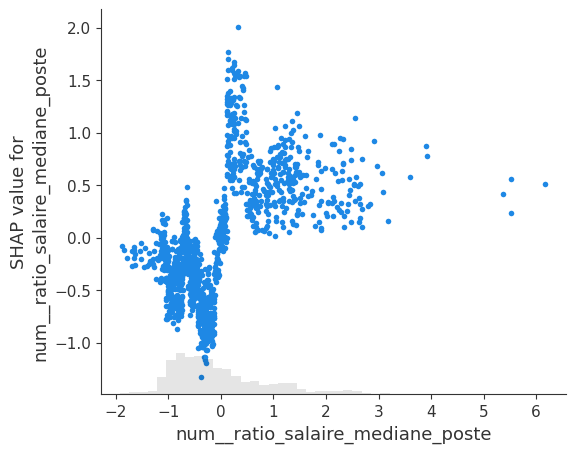

In [111]:
shap.plots.scatter(
    explanation[:, "num__ratio_salaire_mediane_poste"]
)

Ce graphique confirme le Beeswarm Plot, être payé au-dessus de la médiane de son poste est associée à un risque plus fort de départ. Cela pourrait s'interpréter comme un "plafond de carrière", l'employé a atteint le plafond de salaire pour son poste, il ne peut plus progresser sans promotion, ce qui entraine un risque de démission pour chercher mieux ailleurs.

Utilisons maintenant l'argument `color=explanation`pour voir quelle variable interagit le plus avec le ratio salaire median poste.

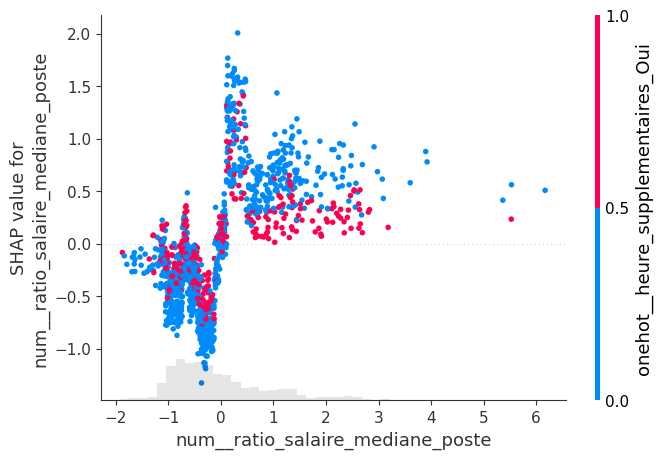

In [112]:
shap.plots.scatter(
    explanation[:, "num__ratio_salaire_mediane_poste"],
    color=explanation
)

On observe que c'est surtout lorsqu'il ne fait pas d'heures supplémentaires que le salaire relatif devient un motif de départ. Interprétation possible (à confirmer) ; le modèle a déjà "dépensé" l'essentiel du risque de départ sur la variable heures supplémentaires, donc le ratio salarial y contribue moins en marginal.

### Feature importance locale : Waterfall plot

Regardons maintenant quelques examples parlants issus des 2 classes ;
- `idx_part_sur` : parmi les employés réellement partis (y_arr == 1), celui dont la proba de départ est la plus haute. Le modèle a vu juste avec confiance → cascade « manuel », tout pousse dans le même sens.
- `idx_reste_sur` : le miroir, parmi les restés. Cascade dominée par les barres bleues.
- `idx_faux_positif` : le modèle prédit le départ, l'employé reste.
- `idx_limite`: le modèle hésite.
- `idx_erreur` : le cas où le modèle s'est le plus trompé.

In [113]:
seuil = resultats_optimise['seuil_optimal']

proba_depart = pipeline_optimise.predict_proba(X_train)[:, 1]

# y_train doit être aligné en position avec X_train_transforme.
# .values enlève l'index pandas pour raisonner en positions entières (0,1,2...).
y_arr = y_train.values if hasattr(y_train, "values") else np.asarray(y_train)

restes = np.where(y_arr == 0)[0]
partis = np.where(y_arr == 1)[0]

idx_part_sur     = partis[np.argmax(proba_depart[partis])]                    # parti, modèle très sûr
idx_reste_sur    = restes[np.argmin(proba_depart[restes])]                    # resté, modèle très sûr
idx_faux_positif = restes[np.argmax(proba_depart[restes])]                    # resté mais cru parti
idx_limite       = np.argmin(np.abs(proba_depart - seuil))                    # un cas d'hésitation

for nom, i in [("Parti (sûr)", idx_part_sur), ("Resté (sûr)", idx_reste_sur),
               ("Faux positif", idx_faux_positif), ("Cas limite", idx_limite)
               ]:
    pred = int(proba_depart[i] >= seuil)
    print(f"{nom:14s} → pos {i:4d} | réel={y_arr[i]} | proba={proba_depart[i]:.3f} | prédit={pred}")

Parti (sûr)    → pos  381 | réel=1 | proba=0.997 | prédit=1
Resté (sûr)    → pos   11 | réel=0 | proba=0.000 | prédit=0
Faux positif   → pos  687 | réel=0 | proba=0.837 | prédit=1
Cas limite     → pos  748 | réel=0 | proba=0.372 | prédit=1


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


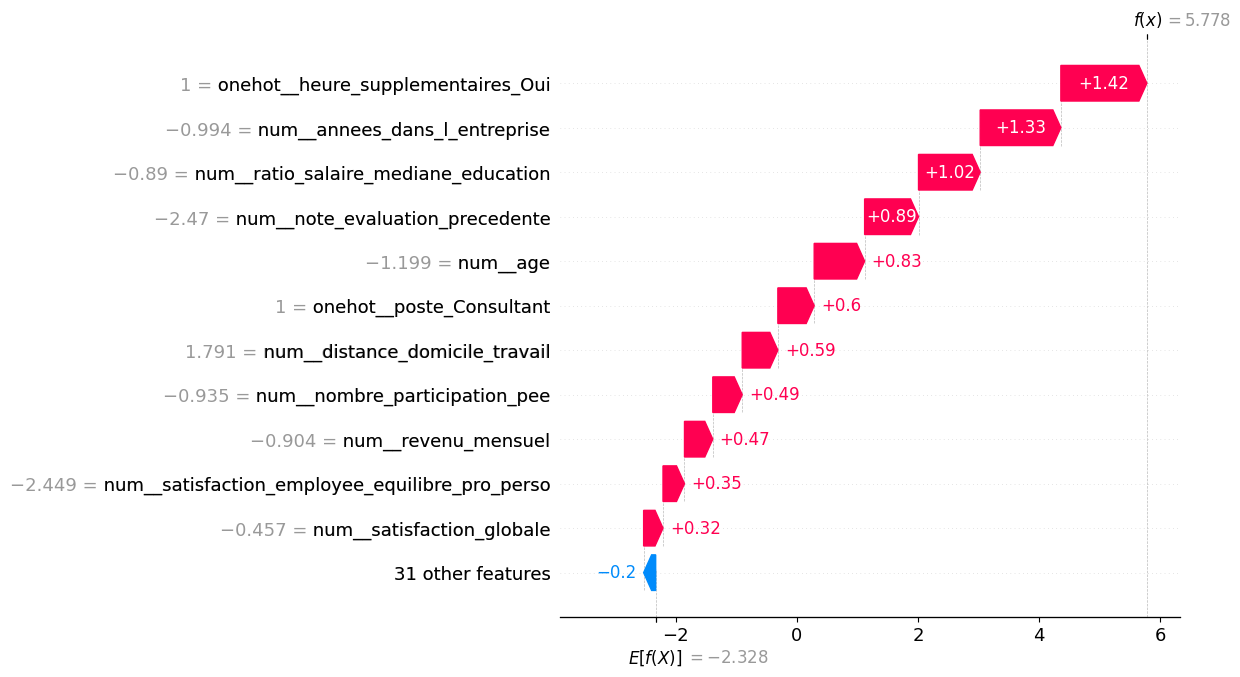

In [114]:
shap.plots.waterfall(explanation[idx_part_sur], max_display=12)

Le modèle était très confiant que l'employé partirait, toutes les top features indiquaient un départ, et en effet l'employé est parti

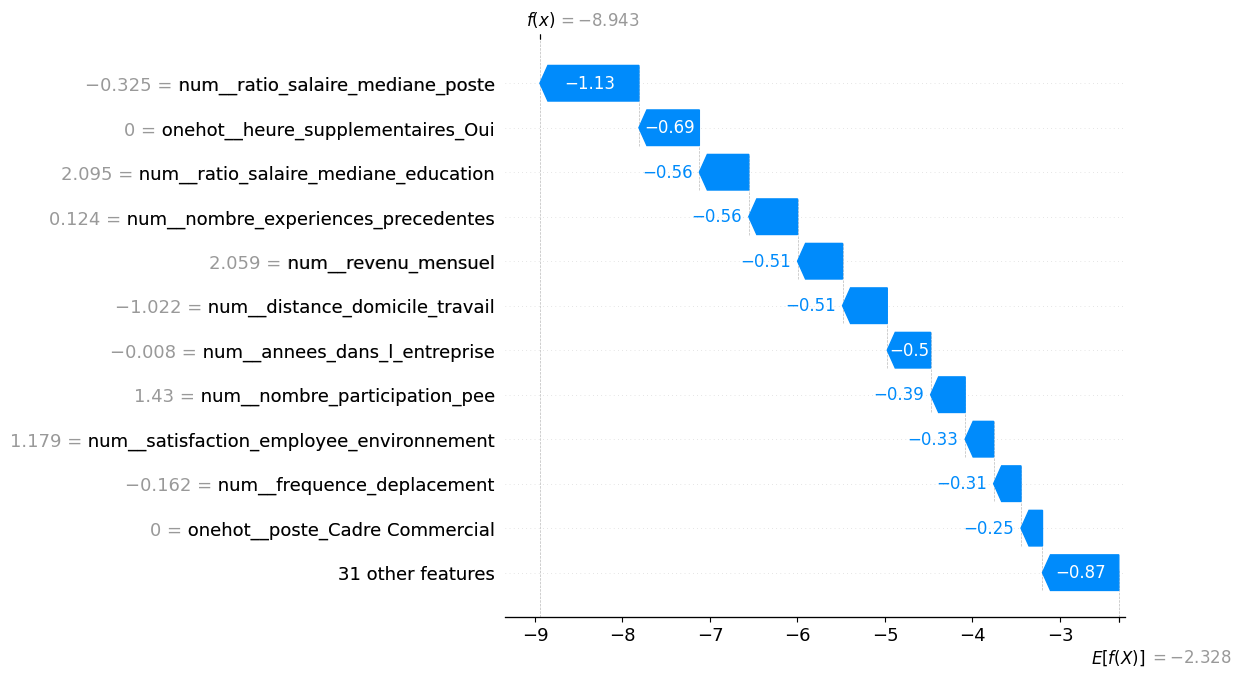

In [115]:
# Employé resté, modèle confiant
shap.plots.waterfall(explanation[idx_reste_sur], max_display=12)

Le scénario inverse, toutes les top features indiquaient que l'employé resterait, et en effet il est resté.

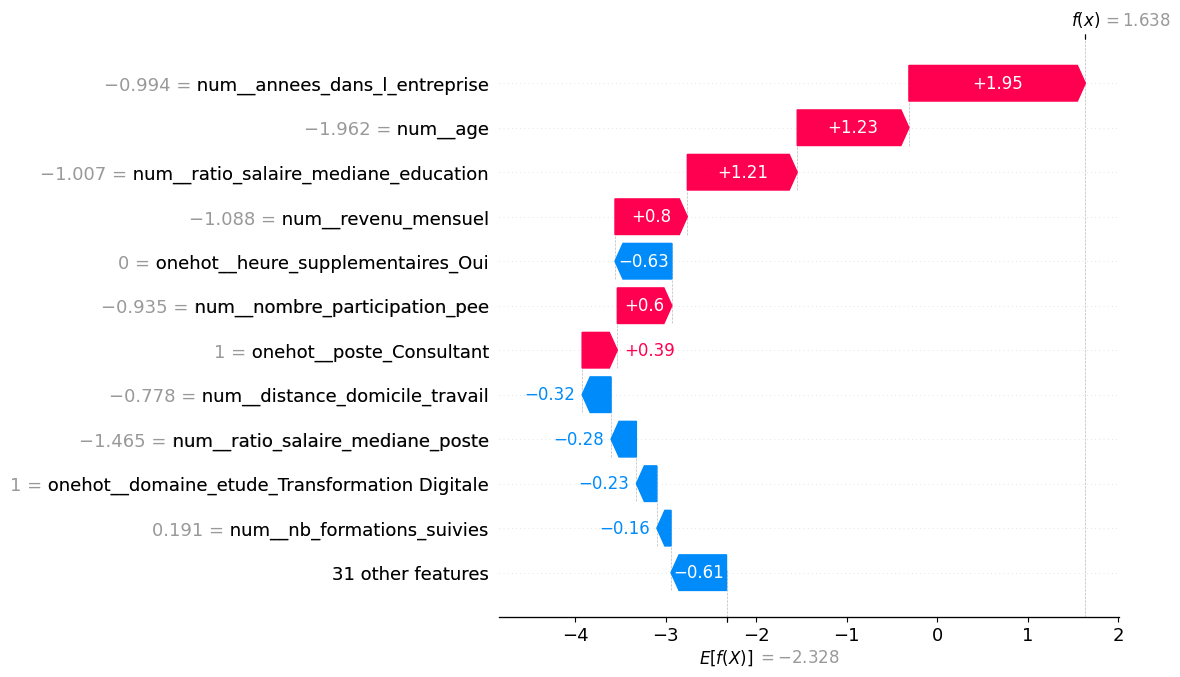

In [116]:
shap.plots.waterfall(explanation[idx_faux_positif], max_display=12)

Cas très intéressant, le modèle prédisait le départ et pourtant l'employé est resté. Les 3 critères clés pour prédire le départ ;
- très peu d'expérience dans l'entreprise (`num_annees_dans_l_entreprise`négatif)
- sous-payé vs la médiane de son niveau d'éducation (`num_ratio_salaire_mediane_education`négatif)
- très jeune (`num_age` négatif)

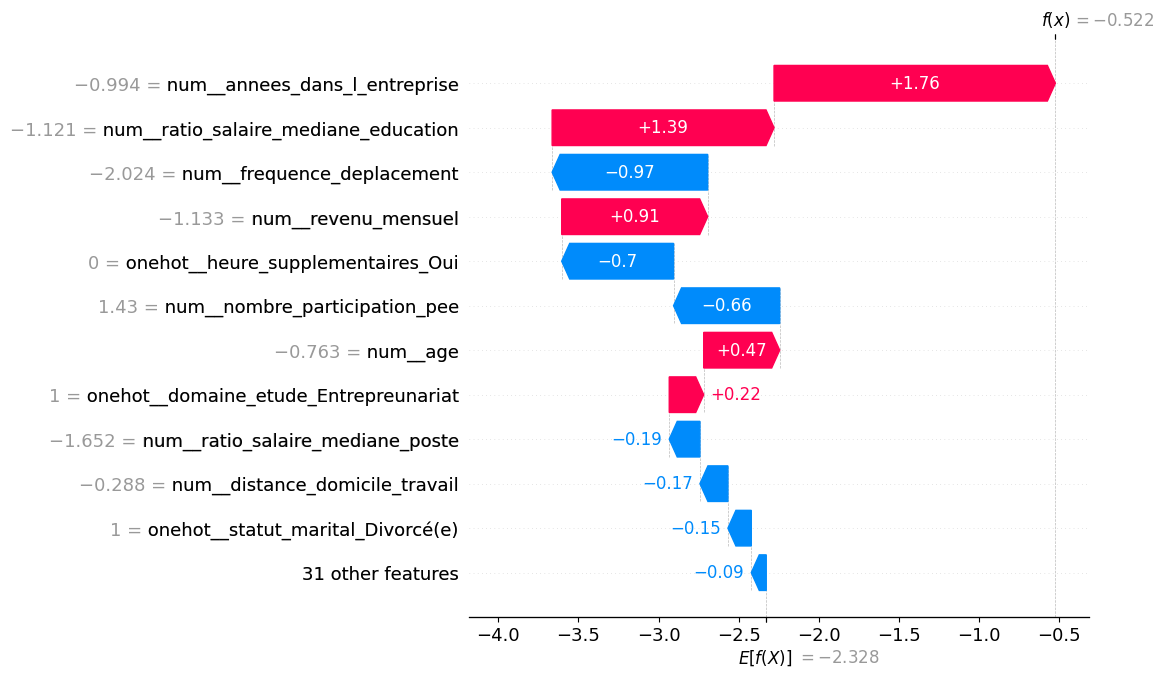

In [117]:
shap.plots.waterfall(explanation[idx_limite], max_display=12)

Cas très intéressant également, le modèle est à la limite, sa proba de départ est à 0.372 et le seuil à 0.371 ; il prédit donc que l'employé va partir (mais l'employé reste)

### Evaluation finale

In [118]:
seuil_optimal_opt = resultats_optimise['seuil_optimal']
print(f"Seuil figé (issu de la CV train) : {seuil_optimal_opt:.3f}")

Seuil figé (issu de la CV train) : 0.371


In [119]:
y_proba_test_opt = pipeline_optimise.predict_proba(X_test)[:, 1]
y_pred_test_opt = (y_proba_test_opt >= seuil_optimal_opt).astype(int)

recall_test    = recall_score(y_test, y_pred_test_opt)
precision_test = precision_score(y_test, y_pred_test_opt)
f2_test        = fbeta_score(y_test, y_pred_test_opt, beta=2)
f1_test        = f1_score(y_test, y_pred_test_opt)

f2_cv        = resultats_optimise['f_beta_optimal']
recall_cv    = resultats_optimise['recall_optimal']
precision_cv = resultats_optimise['precision_optimal']

print(f"=== Évaluation finale — LightGBM tuné (Optuna) sur X_test ({len(y_test)} employés) ===\n")
print(f"Seuil appliqué : {seuil_optimal_opt:.3f} (déterminé en CV sur X_train)\n")
print(f"{'Métrique':<12} {'CV (attendu)':<15} {'X_test (réel)':<15} {'Écart':<10}")
print(f"{'-'*52}")
print(f"{'F2-score':<12} {f2_cv:<15.3f} {f2_test:<15.3f} {f2_test-f2_cv:+.3f}")
print(f"{'Recall':<12} {recall_cv:<15.3f} {recall_test:<15.3f} {recall_test-recall_cv:+.3f}")
print(f"{'Précision':<12} {precision_cv:<15.3f} {precision_test:<15.3f} {precision_test-precision_cv:+.3f}")
print(f"\nF1-score sur X_test : {f1_test:.3f} (pour info)")

=== Évaluation finale — LightGBM tuné (Optuna) sur X_test (294 employés) ===

Seuil appliqué : 0.371 (déterminé en CV sur X_train)

Métrique     CV (attendu)    X_test (réel)   Écart     
----------------------------------------------------
F2-score     0.644           0.514           -0.130
Recall       0.700           0.553           -0.147
Précision    0.487           0.400           -0.087

F1-score sur X_test : 0.464 (pour info)


/Users/matthieu/dev/openclassrooms/projet4/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


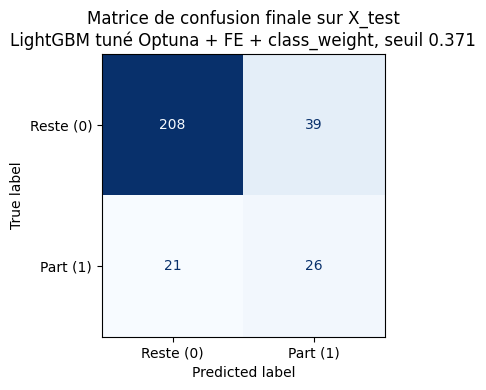

In [120]:
cm = confusion_matrix(y_test, y_pred_test_opt)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    cm, display_labels=['Reste (0)', 'Part (1)']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(
    f"Matrice de confusion finale sur X_test\n"
    f"LightGBM tuné Optuna + FE + class_weight, seuil {seuil_optimal_opt:.3f}"
)
plt.tight_layout()
plt.show()


**Lecture métier de la matrice de confusion**

Sur les 294 employés de X_test, dont 47 partent réellement :
- **26 départs détectés** (vrais positifs) — soit 55% des départs anticipés
- **21 départs ratés** (faux négatifs) — coût RH lourd : turnover non anticipé
- **39 fausses alertes** (faux positifs) — coût RH limité : pour actions à déterminer (entretien préventif, prime de fidélisation, ...)
- **208 employés correctement identifiés comme restants** (vrais négatifs)

Ce compromis est également cohérent avec le choix de la métrique de score (F2-score, β=2 qui privilégie le recall) : les entretiens préventifs inutiles coutent moins cher que les départs anticipables ratés.

2 remarques supplémentaires :
- Après fine-tuning, on observe un compromis différent du compromis obtenu à la fin de l'étape 4 ; la précision est bien meilleure mais le recall est moins bon.
- le f2-score après fine-tuning est moins bon (0.514 vs 0.587), mais le fine-tuning a l'avantage de présenter un seuil explicable plus facilement au métier (0.37 au lieu de 0.05)

### Comparaison avec la régression logistique

L'énoncé (étapes 4 et 5) demandait explicitement de tester et d'optimiser un modèle non-linéaire. Cela dit, la régression logistique optimisée affichait le meilleur F2 en validation croisée (0,66).
Regardons son score sur le jeu de test.

=== Régression logistique (class_weight) sur X_test ===
Recall    : 0.745
Précision : 0.380
F2-score  : 0.625
F1-score  : 0.504


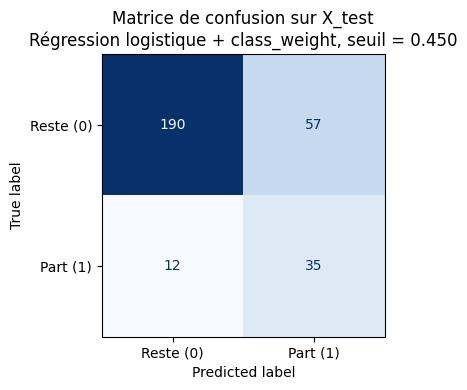

In [121]:
pipeline_logreg = pipelines_weights['LogisticRegression_weights']
# Version avec seuil optimisé (cohérente avec ta démarche F2)
pipeline_logreg.fit(X_train, y_train)

y_proba_test_lr = pipeline_logreg.predict_proba(X_test)[:, 1]

seuil_lr = resultats_seuils['LogisticRegression_weights']['seuil_optimal']
y_pred_test_lr = (y_proba_test_lr >= seuil_lr).astype(int)

recall_lr    = recall_score(y_test, y_pred_test_lr)
precision_lr = precision_score(y_test, y_pred_test_lr)
f2_lr        = fbeta_score(y_test, y_pred_test_lr, beta=2)
f1_lr        = f1_score(y_test, y_pred_test_lr)

print("=== Régression logistique (class_weight) sur X_test ===")
print(f"Recall    : {recall_lr:.3f}")
print(f"Précision : {precision_lr:.3f}")
print(f"F2-score  : {f2_lr:.3f}")
print(f"F1-score  : {f1_lr:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test_lr,
    display_labels=['Reste (0)', 'Part (1)'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f"Matrice de confusion sur X_test\nRégression logistique + class_weight, seuil = {seuil_lr:.3f}")
plt.tight_layout()
plt.show()

La régression logistique obtient effectivement un meilleur f2-score sur le jeu de test, à 0.625 (très proche du score de la validation croisée, à 0.66).

Sur les 294 employés de X_test, dont 47 partent réellement :
- **35 départs détectés** (vrais positifs) — soit 74% de recall (contre 55% pour LightGBM fine tuné)
- **12 départs ratés** (faux négatifs) — coût RH lourd : turnover non anticipé
- **57 fausses alertes** (faux positifs) — soit 38% de précision (vs 40% pour LightGBM)
- **190 employés correctement identifiés comme restants** (vrais négatifs)

### Tableau comparatif

In [122]:
colonnes = [
    "Configuration", "Seuil opti",
    "F2 CV (défaut)", "F2 CV (opti)", "Rappel CV (opti)", "Précision CV (opti)",
    "F2 test", "Rappel test", "Précision test",
]

donnees = [
    # config                              seuil  F2cvdéf F2cvopt Rcvopt  Pcvopt  F2te    Rte     Pte
    ["Régression log. + class_weight",    0.450, 0.632,  0.660,  0.821,  0.370,  None,   None,   None],
    ["Régression log. + FE",              0.480, 0.650,  0.658,  0.779,  0.405,  0.625,  0.745,  0.38],
    ["LightGBM + class_weight",           0.044, 0.500,  0.618,  0.800,  0.323,  None,   None,   None],
    ["LightGBM + FE",                     0.049, 0.462,  0.628,  0.779,  0.353,  0.587,  0.745,  0.318],
    ["LightGBM + FE + Optuna (retenu)",   0.371,  None,  0.644,   0.7,   0.487,  0.514,  0.553,  0.4],
    ["RandomForest + class_weight",       0.190, 0.180,  0.625,  0.716,  0.415,  None,   None,   None],
    ["RandomForest + FE",                 0.140, 0.174,  0.608,  0.800,  0.311,  None,   None,   None],
]

recap = pd.DataFrame(donnees, columns=colonnes).set_index("Configuration")

recap.round(3).fillna("—")

,Seuil opti,F2 CV (défaut),F2 CV (opti),Rappel CV (opti),Précision CV (opti),F2 test,Rappel test,Précision test
Configuration,,,,,,,,
Régression log. + class_weight,0.450,0.632,0.660,0.821,0.370,—,—,—
Régression log. + FE,0.480,0.65,0.658,0.779,0.405,0.625,0.745,0.38
LightGBM + class_weight,0.044,0.5,0.618,0.800,0.323,—,—,—
LightGBM + FE,0.049,0.462,0.628,0.779,0.353,0.587,0.745,0.318
LightGBM + FE + Optuna (retenu),0.371,—,0.644,0.700,0.487,0.514,0.553,0.4
RandomForest + class_weight,0.190,0.18,0.625,0.716,0.415,—,—,—
RandomForest + FE,0.140,0.174,0.608,0.800,0.311,—,—,—


### Conclusion

#### Résultat du modèle

Le modèle final retenu est un **LightGBM** avec feature engineering et dont les hyperparamètres ont été optimisés par Optuna, avec un **seuil de décision de 0,37** déterminé par validation croisée sur le jeu d'entraînement (optimisation du F2-score).

Sur le **jeu de test**, le modèle obtient un **F2-score de 0,514** (recall 0,55, précision 0,40). À comparer aux **0,645 estimés en validation croisée**, soit un écart de **−0,13**. Cet écart pourrait s'expliquer par trois facteurs :
- un léger sur-apprentissage du fine-tuning (Optuna optimise sur la CV, le test n'en profite pas) ;
- la variance d'un jeu de test de taille réduite (294 employés, dont ~50 départs réels) ;
- mon F2-score en validation croisée est une borne supérieure optimiste : le seuil de décision est choisi par argmax du F2 sur les prédictions out-of-fold, puis évalué sur ces mêmes prédictions.

Le fine-tuning a fait légèrement **baisser** le F2 sur le test (0,514 vs 0,587 avant fine-tuning), mais il produit un modèle **mieux calibré** : le seuil optimal remonte de 0,05 à 0,37, signe que les probabilités prédites ne sont plus tassées vers le bas. Les scores deviennent ainsi exploitables comme un véritable risque de départ — ce qui compte davantage que 0,07 de F2 si l'objectif est de **classer** les employés par niveau de risque.

**Mon estimation honnête de la performance en production est donc ~0,51**, et non 0,645. Ce résultat reste très au-dessus de la baseline (la régression logistique brute de l'étape 3, au seuil 0,5, F2 ≈ 0,4).

#### Enseignements métier

L'interprétation du modèle (importance native, permutation importance, SHAP) fait ressortir ces facteurs de départ :

- **Heures supplémentaires** : driver le plus net et le plus stable (n°1 en SHAP comme en permutation).
- **Salaire** (absolu et relatif au poste / à l'éducation) et **participation au PEE** : leviers économiques, particulièrement ressortis après le feature engineering.
- **Ancienneté** et **âge** : les profils jeunes et peu anciens partent davantage.
- **Satisfaction globale** : facteur classique, présent mais secondaire dans ce modèle.

#### Limites

- **Associations, pas causalité.** Toutes mes analyses d'importance décrivent les associations apprises par le modèle, pas des relations causales. Un facteur « associé au départ » ne signifie pas qu'agir dessus réduira les départs.
- **Taille du jeu de test** (294 employés) : les métriques sont sensibles à l'échantillonnage, d'où une part d'incertitude sur le F2 final.
- **Léger sur-apprentissage** révélé par l'écart CV/test (−0,13).

#### Perspectives

- Un **jeu de données plus volumineux** réduirait la variance et l'écart CV/test.
- Pour passer de l'association à la **causalité**, une démarche expérimentale (A/B test sur une mesure de rétention) serait indispensable.
- **Régression logistique plus adaptée** L'énoncé (étapes 4 et 5) demandait explicitement de tester et d'optimiser un modèle non-linéaire. Cela dit, la régression logistique optimisée affichait le meilleur F2 en validation croisée (0,66), et affiche effectivement le meilleur F2 score sur le jeu de test (0.625), avec notamment un bien meilleur recall.

#### Recommandation

Ce modèle doit être utilisé comme un **outil d'alerte** pour identifier les employés à risque et **cibler les entretiens de rétention** — pas comme un oracle. Le choix du F2 (β=2) privilégie volontairement le **recall** : mieux vaut quelques fausses alertes (entretiens « inutiles ») que de manquer un départ réel, plus coûteux pour l'entreprise.